# Cell 1 — Setup: Environment, GEE Initialization, AOI, and Output Folder

This cell initializes the Week 13 ARIA v9.0 homework environment.  
It imports required packages, connects to Google Earth Engine, defines the Xiulin / Taroko study area, sets key event dates, and creates the `output/` folder for saving local figures, CSV tables, and homework results.

In [1]:
# ============================================================================
# Cell 1 — Setup: Environment, GEE Initialization, AOI, and Output Folder
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Import core packages
# ----------------------------------------------------------------------------

import os
from pathlib import Path
from datetime import datetime, timedelta

import ee
import geemap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ----------------------------------------------------------------------------
# 2. Define project folder structure
# ----------------------------------------------------------------------------
# Your actual project structure:
#
# HW12/
# ├── data/
# ├── output/
# ├── script/
# │   └── HW12.ipynb
# └── Homework-Week13.md
#
# Since this notebook is inside HW12/script/,
# Path.cwd() should be:
#   C:/Users/97000/CascadeProjects/.../HW12/script
#
# Therefore, the project root should be:
#   Path.cwd().parent  → HW12/

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "script":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "output"
SCRIPT_DIR = PROJECT_DIR / "script"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory :", CURRENT_DIR)
print("Project directory :", PROJECT_DIR)
print("Data directory    :", DATA_DIR)
print("Output directory  :", OUTPUT_DIR)
print("Script directory  :", SCRIPT_DIR)


# ----------------------------------------------------------------------------
# 3. Initialize Google Earth Engine
# ----------------------------------------------------------------------------
# If you are using VS Code / Windsurf / Cursor:
# Run this once in Terminal before executing this notebook:
#
#     earthengine authenticate
#
# Then initialize GEE here.
# Replace PROJECT_ID if your Google Cloud Project ID changes.

PROJECT_ID = "rsga-496805"

try:
    ee.Initialize(project=PROJECT_ID)
    print(f"\n✓ GEE initialized with project: {PROJECT_ID}")

except Exception as e:
    print("\n✗ GEE initialization failed.")
    print("Please check:")
    print("1. Did you run `earthengine authenticate` in Terminal?")
    print("2. Is Google Earth Engine API enabled for this project?")
    print("3. Is your PROJECT_ID correct?")
    raise e


# ----------------------------------------------------------------------------
# 4. Define homework study area: Xiulin / Taroko
# ----------------------------------------------------------------------------
# GEE rectangle format:
# [west, south, east, north]
#
# This is the required homework study area.

TAROKO_BBOX = [
    121.34526379253053,  # west
    24.046021742135874,  # south
    121.85149217685861,  # east
    24.35767637905926    # north
]

aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

print("\nStudy area: Xiulin / Taroko")
print("BBOX:", TAROKO_BBOX)


# ----------------------------------------------------------------------------
# 5. Define key dates for Week 13 homework
# ----------------------------------------------------------------------------

S2_START = "2020-01-01"
S2_END   = "2026-03-31"

S1_START = "2022-01-01"
S1_END   = "2026-03-31"

EARTHQUAKE_DATE = "2024-04-03"
EARTHQUAKE_LABEL = "2024 Hualien Earthquake"

PRE_EQ_START  = "2023-01-01"
PRE_EQ_END    = "2024-03-31"

POST_EQ_START = "2024-04-01"
POST_EQ_END   = "2024-09-30"

POST_DAM_START = "2025-10-01"
POST_DAM_END   = "2026-03-31"

print("\nKey dates:")
print("Sentinel-2 period :", S2_START, "to", S2_END)
print("Sentinel-1 period :", S1_START, "to", S1_END)
print("Earthquake date   :", EARTHQUAKE_DATE)
print("Pre-EQ composite  :", PRE_EQ_START, "to", PRE_EQ_END)
print("Post-EQ composite :", POST_EQ_START, "to", POST_EQ_END)
print("Post-Dam composite:", POST_DAM_START, "to", POST_DAM_END)


# ----------------------------------------------------------------------------
# 6. Quick GEE connection test using SRTM DEM
# ----------------------------------------------------------------------------

test_point = ee.Geometry.Point([121.6, 24.2])
dem = ee.Image("USGS/SRTMGL1_003")

elevation = (
    dem.sample(
        region=test_point,
        scale=30
    )
    .first()
    .get("elevation")
    .getInfo()
)

print("\n✓ GEE connection test passed.")
print(f"Sample elevation near Taroko: {elevation} m")


# ----------------------------------------------------------------------------
# 7. Basic plotting style
# ----------------------------------------------------------------------------

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

print("\n✓ Cell 1 completed successfully.")

Current directory : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\script
Project directory : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12
Data directory    : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\data
Output directory  : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output
Script directory  : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\script

✓ GEE initialized with project: rsga-496805

Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]

Key dates:
Sentinel-2 period : 2020-01-01 to 2026-03-31
Sentinel-1 period : 2022-01-01 to 2026-03-31
Earthquake date   : 2024-04-03
Pre-EQ composite  : 2023-01-01 to 2024-03-31
Post-EQ composite : 2024-04-01 to 2024-09-30
Post-Dam composite: 2025-10-01 to 2026-03-31

✓ GEE connection test passed.
Sample elevation near Taroko: 1978 m

✓ 

# Task 1 — NDVI Time Series Analysis
## Cell 2 — Filter Sentinel-2 ImageCollection

This cell filters Sentinel-2 Level-2A imagery over the Xiulin / Taroko study area from 2020-01-01 to 2026-03-31.  
The collection is filtered by AOI, date range, and scene-level cloud cover lower than 40%.  
The image count and metadata summary will be saved to the `output/` folder for later reporting.

In [2]:
# ============================================================================
# Task 1 — NDVI Time Series Analysis
# Cell 2 — Filter Sentinel-2 ImageCollection
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Filter Sentinel-2 Level-2A ImageCollection
# ----------------------------------------------------------------------------
# Dataset:
# COPERNICUS/S2_SR_HARMONIZED
#
# Homework requirement:
# - AOI: Xiulin / Taroko
# - Date range: 2020-01-01 to 2026-03-31
# - Cloud cover: < 40%

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(S2_START, S2_END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
)

s2_count = s2.size().getInfo()

print("Task 1 — Sentinel-2 ImageCollection")
print("--------------------------------------------------")
print(f"Study area        : Xiulin / Taroko")
print(f"Date range        : {S2_START} to {S2_END}")
print(f"Cloud filter      : CLOUDY_PIXEL_PERCENTAGE < 40")
print(f"Total S2 images   : {s2_count}")


# ----------------------------------------------------------------------------
# 2. Inspect the first available image
# ----------------------------------------------------------------------------

first_s2 = ee.Image(s2.first())

first_date = (
    ee.Date(first_s2.get("system:time_start"))
    .format("YYYY-MM-dd")
    .getInfo()
)

first_cloud = first_s2.get("CLOUDY_PIXEL_PERCENTAGE").getInfo()

band_names = first_s2.bandNames().getInfo()

print("\nFirst available image")
print("--------------------------------------------------")
print(f"Date              : {first_date}")
print(f"Cloud percentage  : {first_cloud:.2f}%")
print(f"Band count        : {len(band_names)}")
print(f"Band names        : {band_names}")


# ----------------------------------------------------------------------------
# 3. Convert collection metadata to a local table
# ----------------------------------------------------------------------------
# This table is useful for checking:
# - how many images are available each year
# - whether some months have fewer images
# - data scale comparison in Task 4

s2_meta = s2.aggregate_array("system:time_start").getInfo()
s2_clouds = s2.aggregate_array("CLOUDY_PIXEL_PERCENTAGE").getInfo()

s2_meta_df = pd.DataFrame({
    "time_start": s2_meta,
    "cloud_percentage": s2_clouds
})

s2_meta_df["date"] = pd.to_datetime(
    s2_meta_df["time_start"],
    unit="ms"
)

s2_meta_df["year"] = s2_meta_df["date"].dt.year
s2_meta_df["month"] = s2_meta_df["date"].dt.month
s2_meta_df["year_month"] = s2_meta_df["date"].dt.to_period("M").astype(str)

s2_meta_df = s2_meta_df[
    ["date", "year", "month", "year_month", "cloud_percentage"]
].sort_values("date").reset_index(drop=True)

display(s2_meta_df.head())


# ----------------------------------------------------------------------------
# 4. Save Sentinel-2 metadata summary to output folder
# ----------------------------------------------------------------------------

s2_meta_csv = OUTPUT_DIR / "task1_sentinel2_metadata.csv"
s2_meta_df.to_csv(s2_meta_csv, index=False, encoding="utf-8-sig")

print("\nSaved metadata CSV:")
print(s2_meta_csv)


# ----------------------------------------------------------------------------
# 5. Monthly image count summary
# ----------------------------------------------------------------------------

s2_monthly_count = (
    s2_meta_df
    .groupby("year_month")
    .size()
    .reset_index(name="image_count")
)

s2_monthly_csv = OUTPUT_DIR / "task1_sentinel2_monthly_image_count.csv"
s2_monthly_count.to_csv(s2_monthly_csv, index=False, encoding="utf-8-sig")

print("\nMonthly image count summary:")
display(s2_monthly_count.head(12))

print("\nSaved monthly count CSV:")
print(s2_monthly_csv)


print("\n✓ Cell 2 completed successfully.")

Task 1 — Sentinel-2 ImageCollection
--------------------------------------------------
Study area        : Xiulin / Taroko
Date range        : 2020-01-01 to 2026-03-31
Cloud filter      : CLOUDY_PIXEL_PERCENTAGE < 40
Total S2 images   : 291

First available image
--------------------------------------------------
Date              : 2020-01-06
Cloud percentage  : 26.02%
Band count        : 26
Band names        : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


,date,year,month,year_month,cloud_percentage
0,2020-01-06 02:40:45.118,2020,1,2020-01,26.017449
1,2020-01-11 02:40:44.604,2020,1,2020-01,13.466731
2,2020-01-11 02:40:59.056,2020,1,2020-01,30.384412
3,2020-01-16 02:40:44.357,2020,1,2020-01,21.975510
4,2020-01-16 02:40:58.815,2020,1,2020-01,10.103212



Saved metadata CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task1_sentinel2_metadata.csv

Monthly image count summary:


,year_month,image_count
0,2020-01,8
1,2020-02,4
2,2020-03,5
3,2020-04,2
4,2020-05,4
5,2020-06,5
6,2020-07,5
7,2020-08,4
8,2020-09,5
9,2020-10,3



Saved monthly count CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task1_sentinel2_monthly_image_count.csv

✓ Cell 2 completed successfully.


# Task 1 — NDVI Time Series Analysis
## Cell 3 — Cloud Masking and NDVI Calculation

This cell defines a Sentinel-2 SCL cloud mask and calculates NDVI for each image.  
The valid SCL classes are vegetation, bare soil, water, and unclassified pixels.  
The output `ndvi_collection` is an ImageCollection containing one NDVI band for each cloud-masked Sentinel-2 image.

In [3]:
# ============================================================================
# Task 1 — NDVI Time Series Analysis
# Cell 3 — Cloud Masking and NDVI Calculation
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define SCL cloud mask + NDVI function
# ----------------------------------------------------------------------------
# Sentinel-2 SCL band classes used here:
#
# 4 = Vegetation
# 5 = Bare soils
# 6 = Water
# 7 = Unclassified
#
# These are kept as "valid" surface observations.
# Cloud, cloud shadow, cirrus, snow, and invalid pixels are masked out.
#
# NDVI:
# NDVI = (NIR - Red) / (NIR + Red)
# Sentinel-2:
# B8 = NIR
# B4 = Red

def mask_and_ndvi(image):
    """
    Apply SCL-based cloud mask and calculate NDVI.

    Parameters
    ----------
    image : ee.Image
        Sentinel-2 Level-2A image.

    Returns
    -------
    ee.Image
        Single-band NDVI image with original time metadata.
    """

    scl = image.select("SCL")

    good_mask = (
        scl.eq(4)
        .Or(scl.eq(5))
        .Or(scl.eq(6))
        .Or(scl.eq(7))
    )

    masked = image.updateMask(good_mask)

    ndvi = (
        masked
        .normalizedDifference(["B8", "B4"])
        .rename("NDVI")
        .copyProperties(image, ["system:time_start"])
    )

    return ndvi


# ----------------------------------------------------------------------------
# 2. Apply the function to the Sentinel-2 collection
# ----------------------------------------------------------------------------
# map() sends the function to GEE server-side.
# It does not download images to the local computer.

ndvi_collection = s2.map(mask_and_ndvi)

ndvi_count = ndvi_collection.size().getInfo()

print("Task 1 — NDVI Collection")
print("--------------------------------------------------")
print(f"Input Sentinel-2 images : {s2_count}")
print(f"Output NDVI images      : {ndvi_count}")


# ----------------------------------------------------------------------------
# 3. Inspect one NDVI image
# ----------------------------------------------------------------------------

first_ndvi = ee.Image(ndvi_collection.first())

first_ndvi_date = (
    ee.Date(first_ndvi.get("system:time_start"))
    .format("YYYY-MM-dd")
    .getInfo()
)

first_ndvi_bands = first_ndvi.bandNames().getInfo()

print("\nFirst NDVI image")
print("--------------------------------------------------")
print(f"Date       : {first_ndvi_date}")
print(f"Band names : {first_ndvi_bands}")


# ----------------------------------------------------------------------------
# 4. Quick NDVI value test over AOI
# ----------------------------------------------------------------------------
# This checks whether the NDVI image has valid pixels after masking.
# We use scale=100 to keep the quick test lightweight.

quick_ndvi_stats = (
    first_ndvi
    .reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(
                reducer2=ee.Reducer.minMax(),
                sharedInputs=True
            ),
        geometry=aoi,
        scale=100,
        maxPixels=1e8
    )
    .getInfo()
)

print("\nQuick NDVI statistics for first image")
print("--------------------------------------------------")
print(quick_ndvi_stats)


# ----------------------------------------------------------------------------
# 5. Add an optional preview map
# ----------------------------------------------------------------------------
# This interactive map is useful for visually checking:
# - AOI boundary
# - Whether NDVI values look spatially reasonable
# - Whether masking removed clouds / invalid pixels

ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "green", "darkgreen"]
}

Map_task1_preview = geemap.Map(
    center=[24.20, 121.60],
    zoom=10
)

Map_task1_preview.addLayer(
    first_ndvi.clip(aoi),
    ndvi_vis,
    f"First NDVI image: {first_ndvi_date}"
)

Map_task1_preview.addLayer(
    aoi,
    {"color": "red"},
    "Xiulin / Taroko AOI"
)

Map_task1_preview.addLayerControl()

print("\n✓ Cell 3 completed successfully.")
print("Preview map created below.")

Map_task1_preview

Task 1 — NDVI Collection
--------------------------------------------------
Input Sentinel-2 images : 291
Output NDVI images      : 291

First NDVI image
--------------------------------------------------
Date       : 2020-01-06
Band names : ['NDVI']

Quick NDVI statistics for first image
--------------------------------------------------
{'NDVI_max': 0.9982788296041308, 'NDVI_mean': 0.6646049309771075, 'NDVI_min': -0.5244755244755245}

✓ Cell 3 completed successfully.
Preview map created below.


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Task 1 — NDVI Time Series Analysis
## Cell 4 — Build Monthly NDVI Time Series Table

This cell aggregates the cloud-masked NDVI ImageCollection into monthly statistics.  
For each month, it creates a median NDVI composite and computes mean, min, and max NDVI over the Xiulin / Taroko AOI.  
The resulting table is saved to the `output/` folder for plotting and reporting.

In [4]:
# ============================================================================
# Task 1 — NDVI Time Series Analysis
# Cell 4 — Build Monthly NDVI Time Series Table
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define a helper function for monthly NDVI aggregation
# ----------------------------------------------------------------------------

def compute_monthly_ndvi_table(
    ndvi_col,
    region,
    start_date,
    end_date,
    scale=100
):
    """
    Compute monthly NDVI statistics from an ee.ImageCollection.

    For each month:
    1. Filter NDVI collection by date.
    2. Build a monthly median NDVI composite.
    3. Reduce the composite over the AOI.
    4. Return mean, min, max, and image count.

    Parameters
    ----------
    ndvi_col : ee.ImageCollection
        Cloud-masked NDVI image collection.
    region : ee.Geometry
        Study area geometry.
    start_date : str
        Start date, format YYYY-MM-DD.
    end_date : str
        End date, format YYYY-MM-DD.
    scale : int
        Spatial scale for reduceRegion. Use 100 m for time-series efficiency.

    Returns
    -------
    pd.DataFrame
        Monthly NDVI statistics table.
    """

    start_y = int(start_date[:4])
    end_y = int(end_date[:4])

    records = []

    for year in range(start_y, end_y + 1):

        for month in range(1, 13):

            month_start = f"{year}-{month:02d}-01"

            if month < 12:
                month_end = f"{year}-{month + 1:02d}-01"
            else:
                month_end = f"{year + 1}-01-01"

            # Stop when exceeding the homework end date
            if month_start > end_date:
                break

            monthly_col = (
                ndvi_col
                .filterDate(month_start, month_end)
                .select("NDVI")
            )

            image_count = monthly_col.size().getInfo()

            # No image available in this month
            if image_count == 0:
                records.append({
                    "date": datetime(year, month, 15),
                    "year": year,
                    "month": month,
                    "year_month": f"{year}-{month:02d}",
                    "image_count": 0,
                    "ndvi_mean": np.nan,
                    "ndvi_min": np.nan,
                    "ndvi_max": np.nan,
                    "ndvi_spread": np.nan
                })

                print(f"{year}-{month:02d}: no image")
                continue

            # Monthly median composite
            monthly_median = monthly_col.median()

            # AOI statistics
            stats = (
                monthly_median
                .reduceRegion(
                    reducer=(
                        ee.Reducer.mean()
                        .combine(
                            reducer2=ee.Reducer.minMax(),
                            sharedInputs=True
                        )
                    ),
                    geometry=region,
                    scale=scale,
                    maxPixels=1e8
                )
                .getInfo()
            )

            ndvi_mean = stats.get("NDVI_mean", np.nan)
            ndvi_min = stats.get("NDVI_min", np.nan)
            ndvi_max = stats.get("NDVI_max", np.nan)

            if (
                ndvi_min is not None
                and ndvi_max is not None
            ):
                ndvi_spread = ndvi_max - ndvi_min
            else:
                ndvi_spread = np.nan

            records.append({
                "date": datetime(year, month, 15),
                "year": year,
                "month": month,
                "year_month": f"{year}-{month:02d}",
                "image_count": image_count,
                "ndvi_mean": ndvi_mean,
                "ndvi_min": ndvi_min,
                "ndvi_max": ndvi_max,
                "ndvi_spread": ndvi_spread
            })

            print(
                f"{year}-{month:02d}: "
                f"n={image_count:2d}, "
                f"mean={ndvi_mean:.4f}, "
                f"min={ndvi_min:.4f}, "
                f"max={ndvi_max:.4f}, "
                f"spread={ndvi_spread:.4f}"
            )

    df = pd.DataFrame(records)

    return df


# ----------------------------------------------------------------------------
# 2. Compute monthly NDVI statistics for the homework period
# ----------------------------------------------------------------------------

print("Computing monthly NDVI statistics for Xiulin / Taroko...")
print("This may take a few minutes because each month is reduced on GEE.\n")

task1_ndvi_monthly_df = compute_monthly_ndvi_table(
    ndvi_col=ndvi_collection,
    region=aoi,
    start_date=S2_START,
    end_date=S2_END,
    scale=100
)


# ----------------------------------------------------------------------------
# 3. Save results to output folder
# ----------------------------------------------------------------------------

task1_ndvi_csv = OUTPUT_DIR / "task1_monthly_ndvi_timeseries.csv"

task1_ndvi_monthly_df.to_csv(
    task1_ndvi_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved monthly NDVI time series CSV:")
print(task1_ndvi_csv)


# ----------------------------------------------------------------------------
# 4. Display summary table
# ----------------------------------------------------------------------------

print("\nMonthly NDVI table preview:")
display(task1_ndvi_monthly_df.head(12))

print("\nMonthly NDVI descriptive statistics:")
display(
    task1_ndvi_monthly_df[
        ["image_count", "ndvi_mean", "ndvi_min", "ndvi_max", "ndvi_spread"]
    ].describe()
)


# ----------------------------------------------------------------------------
# 5. Identify missing or low-image months
# ----------------------------------------------------------------------------

missing_months = task1_ndvi_monthly_df[
    task1_ndvi_monthly_df["image_count"] == 0
]

low_image_months = task1_ndvi_monthly_df[
    (task1_ndvi_monthly_df["image_count"] > 0)
    & (task1_ndvi_monthly_df["image_count"] <= 2)
]

print("\nMissing months:")
if len(missing_months) == 0:
    print("No missing months after cloud filtering.")
else:
    display(missing_months[["year_month", "image_count"]])

print("\nLow-image months, image_count <= 2:")
if len(low_image_months) == 0:
    print("No low-image months.")
else:
    display(low_image_months[["year_month", "image_count", "ndvi_mean"]])


print("\n✓ Cell 4 completed successfully.")

Computing monthly NDVI statistics for Xiulin / Taroko...
This may take a few minutes because each month is reduced on GEE.

2020-01: n= 8, mean=0.4580, min=-0.5335, max=0.9985, spread=1.5321
2020-02: n= 4, mean=0.4609, min=-0.5850, max=0.9945, spread=1.5795
2020-03: n= 5, mean=0.4302, min=-0.4698, max=0.9845, spread=1.4543
2020-04: n= 2, mean=0.4810, min=-0.2080, max=0.9368, spread=1.1449
2020-05: n= 4, mean=0.4345, min=-0.4079, max=0.9635, spread=1.3715
2020-06: n= 5, mean=0.5438, min=-0.5507, max=0.9494, spread=1.5001
2020-07: n= 5, mean=0.5272, min=-0.3729, max=0.9402, spread=1.3132
2020-08: n= 4, mean=0.5077, min=-0.8151, max=0.9807, spread=1.7959
2020-09: n= 5, mean=0.4912, min=-0.4067, max=0.9576, spread=1.3643
2020-10: n= 3, mean=0.4823, min=-0.6128, max=0.9827, spread=1.5955
2020-11: n= 5, mean=0.4984, min=-0.5213, max=0.9984, spread=1.5197
2020-12: n= 2, mean=0.3487, min=-0.7817, max=0.9985, spread=1.7802
2021-01: n= 6, mean=0.4936, min=-0.6039, max=1.0000, spread=1.6039
2021-

,date,year,month,year_month,image_count,ndvi_mean,ndvi_min,ndvi_max,ndvi_spread
0,2020-01-15,2020,1,2020-01,8,0.458042,-0.533546,0.998532,1.532078
1,2020-02-15,2020,2,2020-02,4,0.460889,-0.584956,0.994536,1.579491
2,2020-03-15,2020,3,2020-03,5,0.430198,-0.469799,0.984496,1.454295
3,2020-04-15,2020,4,2020-04,2,0.481018,-0.208042,0.936842,1.144884
4,2020-05-15,2020,5,2020-05,4,0.434514,-0.407942,0.963542,1.371484
5,2020-06-15,2020,6,2020-06,5,0.543834,-0.550725,0.949357,1.500081
6,2020-07-15,2020,7,2020-07,5,0.527179,-0.372916,0.940238,1.313154
7,2020-08-15,2020,8,2020-08,4,0.507691,-0.815126,0.980746,1.795872
8,2020-09-15,2020,9,2020-09,5,0.491247,-0.406655,0.957640,1.364295
9,2020-10-15,2020,10,2020-10,3,0.482266,-0.612818,0.982659,1.595477



Monthly NDVI descriptive statistics:


,image_count,ndvi_mean,ndvi_min,ndvi_max,ndvi_spread
count,75.000000,72.000000,72.000000,72.000000,72.000000
mean,3.880000,0.483304,-0.634854,0.976962,1.611816
std,2.259873,0.084070,0.246076,0.026870,0.253941
min,0.000000,0.212097,-1.000000,0.911300,1.106288
25%,2.000000,0.455175,-0.860960,0.957411,1.409012
50%,4.000000,0.485516,-0.587860,0.992927,1.578612
75%,5.000000,0.513891,-0.443769,1.000000,1.860253
max,10.000000,0.708867,-0.194988,1.000000,2.000000



Missing months:


,year_month,image_count
24,2022-01,0
25,2022-02,0
52,2024-05,0



Low-image months, image_count <= 2:


,year_month,image_count,ndvi_mean
3,2020-04,2,0.481018
11,2020-12,2,0.348677
17,2021-06,2,0.672650
28,2022-05,1,0.631680
29,2022-06,2,0.531474
34,2022-11,2,0.326023
36,2023-01,1,0.662723
37,2023-02,1,0.433704
39,2023-04,2,0.505415
45,2023-10,2,0.486254



✓ Cell 4 completed successfully.


# Task 1 — NDVI Time Series Analysis
## Cell 5 — Plot Monthly NDVI Time Series

This cell visualizes the monthly NDVI statistics from Cell 4.  
It plots mean NDVI, minimum NDVI, maximum NDVI, and the min–max spatial range.  
The 2024 Hualien earthquake is marked with a vertical dashed line.  
The figure is saved to the `output/` folder as a PNG file for homework submission.

In [5]:
# --- 中文字型設定（跨平台：Colab / Windows / macOS 皆適用）---
import matplotlib.font_manager as fm
try:
    import subprocess
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"],
                   capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
except FileNotFoundError:
    pass  # 非 Linux（Windows / macOS），跳過 apt-get
_cjk_candidates = [
    "Microsoft JhengHei",      # Windows 正黑體
    "PingFang TC",             # macOS 蘋方
    "Noto Sans CJK TC",       # Colab / Linux
    "Heiti TC",                # macOS 黑體
    "WenQuanYi Micro Hei",    # Linux
    "Droid Sans Fallback",    # Android / 舊 Linux
]
_available = {f.name for f in fm.fontManager.ttflist}
_cjk_found = [f for f in _cjk_candidates if f in _available]
if _cjk_found:
    plt.rcParams["font.sans-serif"] = _cjk_found + ["DejaVu Sans"]
    print(f"中文字型: {_cjk_found[0]}")
else:
    print("⚠️ 未找到中文字型，中文標題可能顯示為方框")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

中文字型: Microsoft JhengHei


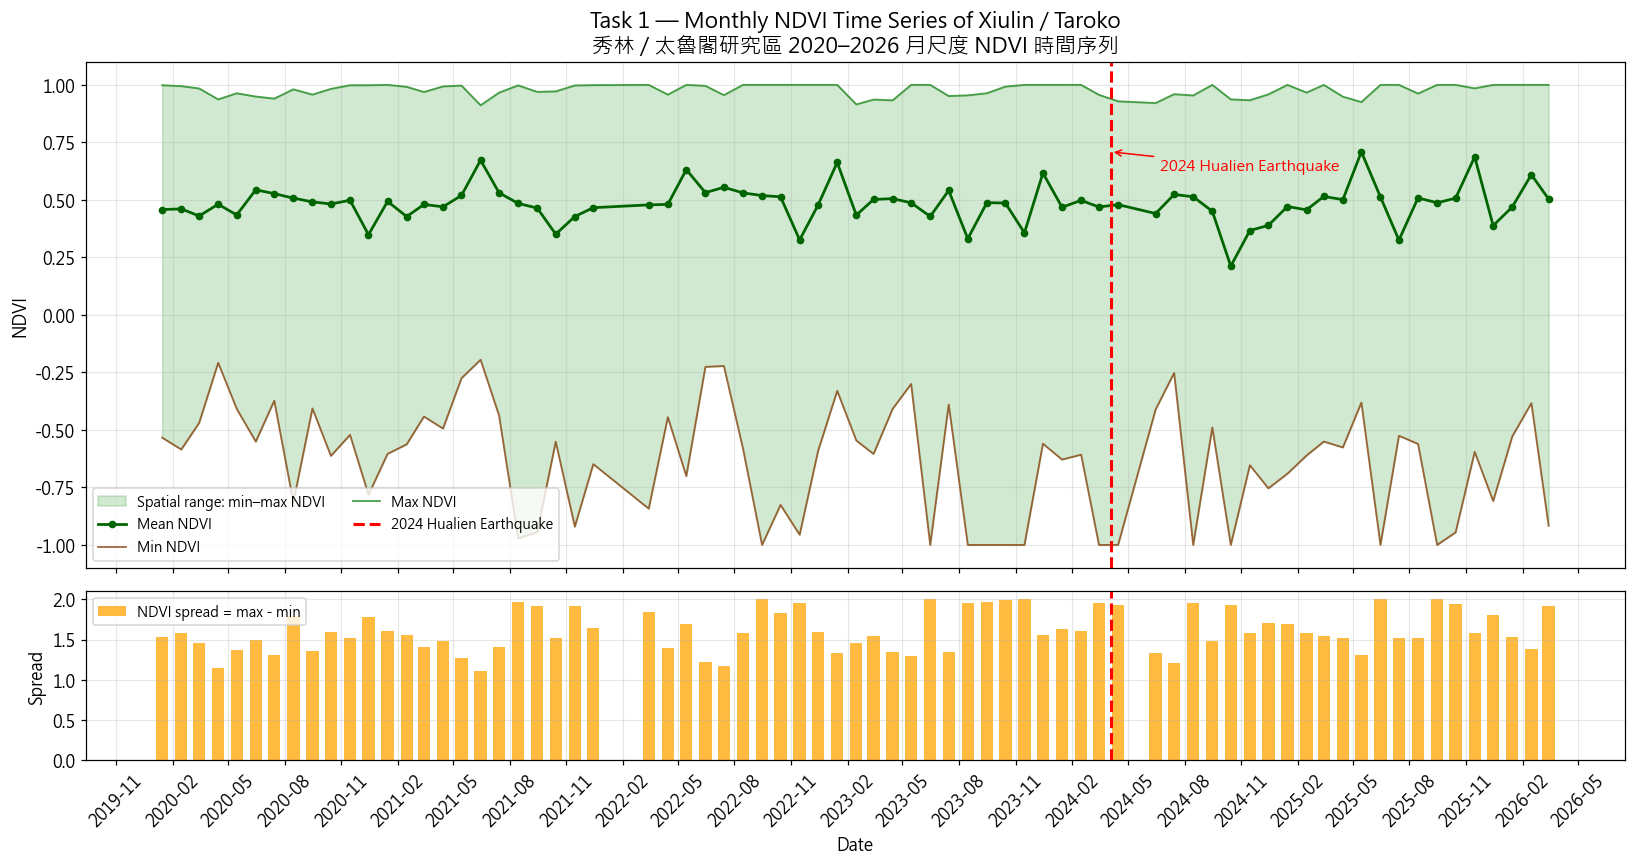

Saved Task 1 NDVI time series figure:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task1_monthly_ndvi_timeseries.png

Task 1 quick summary
--------------------------------------------------
Valid months                 : 72
Missing months               : 3
Missing month list           : ['2022-01', '2022-02', '2024-05']
Mean NDVI before earthquake  : 0.4851
Mean NDVI post earthquake    : 0.4815
Mean NDVI post dam period    : 0.5275

✓ Cell 5 completed successfully.


In [6]:
# ============================================================================
# Task 1 — NDVI Time Series Analysis
# Cell 5 — Plot Monthly NDVI Time Series
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Prepare plotting data
# ----------------------------------------------------------------------------

plot_df = task1_ndvi_monthly_df.copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])

valid_df = plot_df.dropna(
    subset=["ndvi_mean", "ndvi_min", "ndvi_max"]
).copy()

dates = valid_df["date"]
ndvi_mean = valid_df["ndvi_mean"]
ndvi_min = valid_df["ndvi_min"]
ndvi_max = valid_df["ndvi_max"]
ndvi_spread = valid_df["ndvi_spread"]

eq_date = pd.Timestamp(EARTHQUAKE_DATE)


# ----------------------------------------------------------------------------
# 2. Create figure with two panels
# ----------------------------------------------------------------------------
# Upper panel:
# - mean NDVI
# - min NDVI
# - max NDVI
# - shaded min-max range
#
# Lower panel:
# - NDVI spread = max - min
# - higher spread means stronger spatial heterogeneity within AOI

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)


# ----------------------------------------------------------------------------
# 3. Upper panel: NDVI mean / min / max
# ----------------------------------------------------------------------------

ax1.fill_between(
    dates,
    ndvi_min,
    ndvi_max,
    alpha=0.18,
    color="green",
    label="Spatial range: min–max NDVI"
)

ax1.plot(
    dates,
    ndvi_mean,
    marker="o",
    markersize=4,
    linewidth=1.8,
    color="darkgreen",
    label="Mean NDVI"
)

ax1.plot(
    dates,
    ndvi_min,
    linewidth=1.2,
    color="saddlebrown",
    alpha=0.8,
    label="Min NDVI"
)

ax1.plot(
    dates,
    ndvi_max,
    linewidth=1.2,
    color="forestgreen",
    alpha=0.8,
    label="Max NDVI"
)

ax1.axvline(
    eq_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label=EARTHQUAKE_LABEL
)

ax1.annotate(
    EARTHQUAKE_LABEL,
    xy=(eq_date, valid_df["ndvi_mean"].max()),
    xytext=(eq_date + pd.Timedelta(days=80), valid_df["ndvi_mean"].max() - 0.08),
    color="red",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)

ax1.set_ylabel("NDVI")
ax1.set_title(
    "Task 1 — Monthly NDVI Time Series of Xiulin / Taroko\n"
    "秀林 / 太魯閣研究區 2020–2026 月尺度 NDVI 時間序列",
    fontsize=14
)

ax1.legend(
    loc="lower left",
    ncol=2,
    fontsize=9
)

ax1.grid(True, alpha=0.3)


# ----------------------------------------------------------------------------
# 4. Lower panel: NDVI spread
# ----------------------------------------------------------------------------

ax2.bar(
    dates,
    ndvi_spread,
    width=20,
    color="orange",
    alpha=0.75,
    label="NDVI spread = max - min"
)

ax2.axvline(
    eq_date,
    color="red",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel("Spread")
ax2.set_xlabel("Date")
ax2.legend(
    loc="upper left",
    fontsize=9
)

ax2.grid(True, alpha=0.3)


# ----------------------------------------------------------------------------
# 5. Format x-axis
# ----------------------------------------------------------------------------

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)

plt.tight_layout()


# ----------------------------------------------------------------------------
# 6. Save figure to output folder
# ----------------------------------------------------------------------------

task1_plot_path = OUTPUT_DIR / "task1_monthly_ndvi_timeseries.png"

plt.savefig(
    task1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved Task 1 NDVI time series figure:")
print(task1_plot_path)


# ----------------------------------------------------------------------------
# 7. Print quick interpretation values for later writing
# ----------------------------------------------------------------------------

pre_eq_mean = valid_df[
    valid_df["date"] < eq_date
]["ndvi_mean"].mean()

post_eq_mean = valid_df[
    (valid_df["date"] >= eq_date)
    & (valid_df["date"] <= pd.Timestamp(POST_EQ_END))
]["ndvi_mean"].mean()

post_dam_mean = valid_df[
    (valid_df["date"] >= pd.Timestamp(POST_DAM_START))
    & (valid_df["date"] <= pd.Timestamp(POST_DAM_END))
]["ndvi_mean"].mean()

missing_months = plot_df[
    plot_df["image_count"] == 0
]["year_month"].tolist()

print("\nTask 1 quick summary")
print("--------------------------------------------------")
print(f"Valid months                 : {len(valid_df)}")
print(f"Missing months               : {len(missing_months)}")
print(f"Missing month list           : {missing_months}")
print(f"Mean NDVI before earthquake  : {pre_eq_mean:.4f}")
print(f"Mean NDVI post earthquake    : {post_eq_mean:.4f}")
print(f"Mean NDVI post dam period    : {post_dam_mean:.4f}")

print("\n✓ Cell 5 completed successfully.")

# Task 1 — NDVI Time Series Analysis
## Cell 6 — Task 1 Written Analysis

This cell summarizes the NDVI time series results.  
It generates a short 3–5 sentence interpretation covering seasonal patterns, earthquake impacts, and missing-data months.  
The text is saved as a Markdown file in the `output/` folder.

In [7]:
# ============================================================================
# Task 1 — NDVI Time Series Analysis
# Cell 6 — Task 1 Written Analysis
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Extract key values from previous results
# ----------------------------------------------------------------------------

valid_months = len(valid_df)
missing_months_count = len(missing_months)

missing_months_text = (
    ", ".join(missing_months)
    if len(missing_months) > 0
    else "none"
)

ndvi_change_post_eq = post_eq_mean - pre_eq_mean
ndvi_change_post_dam = post_dam_mean - pre_eq_mean

print("Task 1 key values")
print("--------------------------------------------------")
print(f"Valid months                 : {valid_months}")
print(f"Missing months               : {missing_months_count}")
print(f"Missing month list           : {missing_months_text}")
print(f"Mean NDVI before earthquake  : {pre_eq_mean:.4f}")
print(f"Mean NDVI post earthquake    : {post_eq_mean:.4f}")
print(f"Mean NDVI post dam period    : {post_dam_mean:.4f}")
print(f"Post-EQ change               : {ndvi_change_post_eq:+.4f}")
print(f"Post-Dam change              : {ndvi_change_post_dam:+.4f}")


# ----------------------------------------------------------------------------
# 2. Generate Task 1 written analysis
# ----------------------------------------------------------------------------

task1_analysis_md = f"""# Task 1 — NDVI Time Series Analysis

The monthly NDVI time series for the Xiulin / Taroko study area shows clear temporal variability from 2020 to 2026.  
Before the 2024 Hualien earthquake, the mean NDVI was approximately **{pre_eq_mean:.4f}**, while the post-earthquake period had a similar mean NDVI of **{post_eq_mean:.4f}**, indicating that the earthquake impact is not very obvious from the AOI-wide mean value alone.  
However, the min–max range and NDVI spread remain large throughout the time series, suggesting strong spatial heterogeneity within the mountainous study area.  
There are **{missing_months_count}** missing months: **{missing_months_text}**, likely because the Taroko mountain area is frequently affected by clouds, rainfall, and cloud masking during Sentinel-2 image filtering.  
The post-dam period shows a higher mean NDVI of **{post_dam_mean:.4f}**, which may indicate partial vegetation recovery or seasonal differences rather than uniform disaster impact.

## Interpretation in Chinese

秀林 / 太魯閣研究區 2020–2026 年的月尺度 NDVI 時間序列顯示出明顯的時間變動。  
地震前平均 NDVI 約為 **{pre_eq_mean:.4f}**，震後平均 NDVI 約為 **{post_eq_mean:.4f}**，兩者差異不大，表示若只看整個 AOI 的平均值，2024 花蓮地震造成的植被影響並不十分明顯。  
然而，NDVI 的 min–max 範圍與 spread 長期偏大，代表山區內部存在高度空間異質性，局部崩塌或植被損失可能被整體平均值稀釋。  
本時序共有 **{missing_months_count}** 個缺值月份，分別為 **{missing_months_text}**，可能與太魯閣山區多雲、多雨，以及 SCL 雲遮罩後有效像元不足有關。  
堰塞湖後期平均 NDVI 上升至 **{post_dam_mean:.4f}**，可能反映部分植被恢復，也可能受到季節差異與可用影像品質影響。
"""

print("\nGenerated Task 1 analysis:")
print("--------------------------------------------------")
print(task1_analysis_md)


# ----------------------------------------------------------------------------
# 3. Save analysis to output folder
# ----------------------------------------------------------------------------

task1_analysis_path = OUTPUT_DIR / "task1_ndvi_analysis.md"

with open(task1_analysis_path, "w", encoding="utf-8") as f:
    f.write(task1_analysis_md)

print("\nSaved Task 1 analysis Markdown:")
print(task1_analysis_path)


# ----------------------------------------------------------------------------
# 4. Task 1 completion checklist
# ----------------------------------------------------------------------------

print("\nTask 1 completion checklist")
print("--------------------------------------------------")
print("✓ Sentinel-2 ImageCollection filtered")
print("✓ SCL cloud mask applied")
print("✓ NDVI calculated")
print("✓ Monthly NDVI time series table generated")
print("✓ NDVI time series plot saved")
print("✓ Brief analysis written and saved")

print("\n✓ Cell 6 completed successfully.")

Task 1 key values
--------------------------------------------------
Valid months                 : 72
Missing months               : 3
Missing month list           : 2022-01, 2022-02, 2024-05
Mean NDVI before earthquake  : 0.4851
Mean NDVI post earthquake    : 0.4815
Mean NDVI post dam period    : 0.5275
Post-EQ change               : -0.0036
Post-Dam change              : +0.0424

Generated Task 1 analysis:
--------------------------------------------------
# Task 1 — NDVI Time Series Analysis

The monthly NDVI time series for the Xiulin / Taroko study area shows clear temporal variability from 2020 to 2026.  
Before the 2024 Hualien earthquake, the mean NDVI was approximately **0.4851**, while the post-earthquake period had a similar mean NDVI of **0.4815**, indicating that the earthquake impact is not very obvious from the AOI-wide mean value alone.  
However, the min–max range and NDVI spread remain large throughout the time series, suggesting strong spatial heterogeneity within t

# Task 2 — Pre/Post Earthquake Median Composite
## Cell 7 — Build Three-Phase NDVI Composites and ΔNDVI Maps

This cell creates three median NDVI composites for the pre-earthquake, post-earthquake, and post-dam periods.  
It then computes three ΔNDVI layers: earthquake-related change, landslide-dam-related change, and total accumulated change.  
Negative ΔNDVI values indicate vegetation loss or exposed surfaces, while positive values indicate vegetation gain or recovery.

In [8]:
# ============================================================================
# Task 2 — Pre/Post Earthquake Median Composite
# Cell 7 — Build Three-Phase NDVI Composites and ΔNDVI Maps
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Build three-phase NDVI median composites
# ----------------------------------------------------------------------------
# Phase 1: Pre-earthquake baseline
# Phase 2: Post-earthquake immediate impact
# Phase 3: Post-dam / later period

pre_eq_ndvi = (
    ndvi_collection
    .filterDate(PRE_EQ_START, PRE_EQ_END)
    .select("NDVI")
    .median()
    .rename("pre_eq_NDVI")
    .clip(aoi)
)

post_eq_ndvi = (
    ndvi_collection
    .filterDate(POST_EQ_START, POST_EQ_END)
    .select("NDVI")
    .median()
    .rename("post_eq_NDVI")
    .clip(aoi)
)

post_dam_ndvi = (
    ndvi_collection
    .filterDate(POST_DAM_START, POST_DAM_END)
    .select("NDVI")
    .median()
    .rename("post_dam_NDVI")
    .clip(aoi)
)

print("Task 2 — Three-phase NDVI composites created")
print("--------------------------------------------------")
print(f"Pre-EQ period   : {PRE_EQ_START} to {PRE_EQ_END}")
print(f"Post-EQ period  : {POST_EQ_START} to {POST_EQ_END}")
print(f"Post-Dam period : {POST_DAM_START} to {POST_DAM_END}")


# ----------------------------------------------------------------------------
# 2. Compute three ΔNDVI layers
# ----------------------------------------------------------------------------
# delta_eq:
#   post-earthquake NDVI - pre-earthquake NDVI
#
# delta_dam:
#   post-dam NDVI - post-earthquake NDVI
#
# delta_total:
#   post-dam NDVI - pre-earthquake NDVI
#
# Interpretation:
#   negative ΔNDVI = vegetation loss / exposed surface increase
#   positive ΔNDVI = vegetation gain / possible recovery

delta_eq = (
    post_eq_ndvi
    .subtract(pre_eq_ndvi)
    .rename("delta_NDVI_eq")
    .clip(aoi)
)

delta_dam = (
    post_dam_ndvi
    .subtract(post_eq_ndvi)
    .rename("delta_NDVI_dam")
    .clip(aoi)
)

delta_total = (
    post_dam_ndvi
    .subtract(pre_eq_ndvi)
    .rename("delta_NDVI_total")
    .clip(aoi)
)

print("\nΔNDVI layers created")
print("--------------------------------------------------")
print("delta_eq    = post_eq_ndvi - pre_eq_ndvi")
print("delta_dam   = post_dam_ndvi - post_eq_ndvi")
print("delta_total = post_dam_ndvi - pre_eq_ndvi")


# ----------------------------------------------------------------------------
# 3. Count images used in each composite period
# ----------------------------------------------------------------------------

pre_eq_count = (
    ndvi_collection
    .filterDate(PRE_EQ_START, PRE_EQ_END)
    .size()
    .getInfo()
)

post_eq_count = (
    ndvi_collection
    .filterDate(POST_EQ_START, POST_EQ_END)
    .size()
    .getInfo()
)

post_dam_count = (
    ndvi_collection
    .filterDate(POST_DAM_START, POST_DAM_END)
    .size()
    .getInfo()
)

composite_count_df = pd.DataFrame({
    "phase": [
        "pre_eq",
        "post_eq",
        "post_dam"
    ],
    "period": [
        f"{PRE_EQ_START} to {PRE_EQ_END}",
        f"{POST_EQ_START} to {POST_EQ_END}",
        f"{POST_DAM_START} to {POST_DAM_END}"
    ],
    "image_count": [
        pre_eq_count,
        post_eq_count,
        post_dam_count
    ]
})

print("\nImages used in each composite")
display(composite_count_df)


# ----------------------------------------------------------------------------
# 4. Save composite image-count summary
# ----------------------------------------------------------------------------

task2_count_csv = OUTPUT_DIR / "task2_composite_image_counts.csv"

composite_count_df.to_csv(
    task2_count_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved composite image-count summary:")
print(task2_count_csv)


# ----------------------------------------------------------------------------
# 5. Quick AOI statistics for each composite and ΔNDVI layer
# ----------------------------------------------------------------------------

def image_stats_over_aoi(image, band_name, region, scale=100):
    """
    Calculate mean, min, and max statistics for one image band over the AOI.
    """

    stats = (
        image
        .select(band_name)
        .reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(
                    reducer2=ee.Reducer.minMax(),
                    sharedInputs=True
                )
            ),
            geometry=region,
            scale=scale,
            maxPixels=1e8
        )
        .getInfo()
    )

    return stats


stats_pre_eq = image_stats_over_aoi(
    pre_eq_ndvi,
    "pre_eq_NDVI",
    aoi
)

stats_post_eq = image_stats_over_aoi(
    post_eq_ndvi,
    "post_eq_NDVI",
    aoi
)

stats_post_dam = image_stats_over_aoi(
    post_dam_ndvi,
    "post_dam_NDVI",
    aoi
)

stats_delta_eq = image_stats_over_aoi(
    delta_eq,
    "delta_NDVI_eq",
    aoi
)

stats_delta_dam = image_stats_over_aoi(
    delta_dam,
    "delta_NDVI_dam",
    aoi
)

stats_delta_total = image_stats_over_aoi(
    delta_total,
    "delta_NDVI_total",
    aoi
)

task2_stats_df = pd.DataFrame([
    {
        "layer": "pre_eq_NDVI",
        "mean": stats_pre_eq.get("pre_eq_NDVI_mean"),
        "min": stats_pre_eq.get("pre_eq_NDVI_min"),
        "max": stats_pre_eq.get("pre_eq_NDVI_max")
    },
    {
        "layer": "post_eq_NDVI",
        "mean": stats_post_eq.get("post_eq_NDVI_mean"),
        "min": stats_post_eq.get("post_eq_NDVI_min"),
        "max": stats_post_eq.get("post_eq_NDVI_max")
    },
    {
        "layer": "post_dam_NDVI",
        "mean": stats_post_dam.get("post_dam_NDVI_mean"),
        "min": stats_post_dam.get("post_dam_NDVI_min"),
        "max": stats_post_dam.get("post_dam_NDVI_max")
    },
    {
        "layer": "delta_NDVI_eq",
        "mean": stats_delta_eq.get("delta_NDVI_eq_mean"),
        "min": stats_delta_eq.get("delta_NDVI_eq_min"),
        "max": stats_delta_eq.get("delta_NDVI_eq_max")
    },
    {
        "layer": "delta_NDVI_dam",
        "mean": stats_delta_dam.get("delta_NDVI_dam_mean"),
        "min": stats_delta_dam.get("delta_NDVI_dam_min"),
        "max": stats_delta_dam.get("delta_NDVI_dam_max")
    },
    {
        "layer": "delta_NDVI_total",
        "mean": stats_delta_total.get("delta_NDVI_total_mean"),
        "min": stats_delta_total.get("delta_NDVI_total_min"),
        "max": stats_delta_total.get("delta_NDVI_total_max")
    }
])

print("\nTask 2 composite and ΔNDVI summary statistics")
display(task2_stats_df)


# ----------------------------------------------------------------------------
# 6. Save statistics table
# ----------------------------------------------------------------------------

task2_stats_csv = OUTPUT_DIR / "task2_composite_delta_ndvi_stats.csv"

task2_stats_df.to_csv(
    task2_stats_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Task 2 statistics CSV:")
print(task2_stats_csv)


print("\n✓ Cell 7 completed successfully.")

Task 2 — Three-phase NDVI composites created
--------------------------------------------------
Pre-EQ period   : 2023-01-01 to 2024-03-31
Post-EQ period  : 2024-04-01 to 2024-09-30
Post-Dam period : 2025-10-01 to 2026-03-31

ΔNDVI layers created
--------------------------------------------------
delta_eq    = post_eq_ndvi - pre_eq_ndvi
delta_dam   = post_dam_ndvi - post_eq_ndvi
delta_total = post_dam_ndvi - pre_eq_ndvi

Images used in each composite


,phase,period,image_count
0,pre_eq,2023-01-01 to 2024-03-31,49
1,post_eq,2024-04-01 to 2024-09-30,28
2,post_dam,2025-10-01 to 2026-03-31,24



Saved composite image-count summary:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task2_composite_image_counts.csv

Task 2 composite and ΔNDVI summary statistics


,layer,mean,min,max
0,pre_eq_NDVI,0.516010,-0.517520,1.000000
1,post_eq_NDVI,0.518880,-0.277486,0.934870
2,post_dam_NDVI,0.507783,-0.664975,1.000000
3,delta_NDVI_eq,0.002523,-0.907131,0.605154
4,delta_NDVI_dam,-0.011508,-0.855668,0.800351
5,delta_NDVI_total,-0.008050,-0.860056,0.591876



Saved Task 2 statistics CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task2_composite_delta_ndvi_stats.csv

✓ Cell 7 completed successfully.


# Task 2 — Pre/Post Earthquake Median Composite
## Cell 8 — Visualize Three-Phase NDVI Composites and ΔNDVI Maps

This cell creates an interactive geemap map for Task 2.  
It displays the three NDVI median composites and three ΔNDVI layers.  
For ΔNDVI maps, red indicates vegetation loss, white indicates little change, and blue indicates vegetation gain or possible recovery.

In [9]:
# ============================================================================
# Task 2 — Pre/Post Earthquake Median Composite
# Cell 8 — Corrected Visualization of Three-Phase NDVI and ΔNDVI Maps
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Rebuild three-phase NDVI composites with the same band name: "NDVI"
# ----------------------------------------------------------------------------
# Important:
# To avoid band-name mismatch during subtract(), all composites are renamed
# to the same band name: "NDVI".

pre_eq_ndvi_vis = (
    ndvi_collection
    .filterDate(PRE_EQ_START, PRE_EQ_END)
    .select("NDVI")
    .median()
    .rename("NDVI")
    .clip(aoi)
)

post_eq_ndvi_vis = (
    ndvi_collection
    .filterDate(POST_EQ_START, POST_EQ_END)
    .select("NDVI")
    .median()
    .rename("NDVI")
    .clip(aoi)
)

post_dam_ndvi_vis = (
    ndvi_collection
    .filterDate(POST_DAM_START, POST_DAM_END)
    .select("NDVI")
    .median()
    .rename("NDVI")
    .clip(aoi)
)


# ----------------------------------------------------------------------------
# 2. Recalculate ΔNDVI layers with standardized band names
# ----------------------------------------------------------------------------

delta_eq_vis = (
    post_eq_ndvi_vis
    .subtract(pre_eq_ndvi_vis)
    .rename("delta_NDVI_eq")
    .clip(aoi)
)

delta_dam_vis = (
    post_dam_ndvi_vis
    .subtract(post_eq_ndvi_vis)
    .rename("delta_NDVI_dam")
    .clip(aoi)
)

delta_total_vis = (
    post_dam_ndvi_vis
    .subtract(pre_eq_ndvi_vis)
    .rename("delta_NDVI_total")
    .clip(aoi)
)


# ----------------------------------------------------------------------------
# 3. Check whether each layer has valid pixels
# ----------------------------------------------------------------------------

def check_valid_pixels(image, band_name, label):
    """
    Check if an image layer has valid pixels over the AOI.
    """

    stats = (
        image
        .select(band_name)
        .reduceRegion(
            reducer=ee.Reducer.count()
                .combine(
                    reducer2=ee.Reducer.mean(),
                    sharedInputs=True
                ),
            geometry=aoi,
            scale=100,
            maxPixels=1e8
        )
        .getInfo()
    )

    count_key = f"{band_name}_count"
    mean_key = f"{band_name}_mean"

    print(f"{label}")
    print("--------------------------------------------------")
    print(f"Valid pixel count : {stats.get(count_key)}")
    print(f"Mean value        : {stats.get(mean_key)}")
    print("")

    return stats


print("Checking valid pixels for corrected Task 2 layers...\n")

check_valid_pixels(
    pre_eq_ndvi_vis,
    "NDVI",
    "Phase 1 — Pre-EQ NDVI"
)

check_valid_pixels(
    post_eq_ndvi_vis,
    "NDVI",
    "Phase 2 — Post-EQ NDVI"
)

check_valid_pixels(
    post_dam_ndvi_vis,
    "NDVI",
    "Phase 3 — Post-Dam NDVI"
)

check_valid_pixels(
    delta_eq_vis,
    "delta_NDVI_eq",
    "ΔNDVI EQ: Post-EQ − Pre-EQ"
)

check_valid_pixels(
    delta_dam_vis,
    "delta_NDVI_dam",
    "ΔNDVI Dam: Post-Dam − Post-EQ"
)

check_valid_pixels(
    delta_total_vis,
    "delta_NDVI_total",
    "ΔNDVI Total: Post-Dam − Pre-EQ"
)


# ----------------------------------------------------------------------------
# 4. Define visualization parameters
# ----------------------------------------------------------------------------

ndvi_vis_params = {
    "min": 0,
    "max": 0.8,
    "palette": [
        "brown",
        "yellow",
        "green",
        "darkgreen"
    ]
}

delta_vis_params = {
    "min": -0.5,
    "max": 0.5,
    "palette": [
        "red",
        "white",
        "blue"
    ]
}


# ----------------------------------------------------------------------------
# 5. Create corrected interactive map
# ----------------------------------------------------------------------------

Map_task2_corrected = geemap.Map(
    center=[24.20, 121.60],
    zoom=10
)

# NDVI composites
Map_task2_corrected.addLayer(
    pre_eq_ndvi_vis,
    ndvi_vis_params,
    "Phase 1 — Pre-EQ NDVI median",
    shown=True
)

Map_task2_corrected.addLayer(
    post_eq_ndvi_vis,
    ndvi_vis_params,
    "Phase 2 — Post-EQ NDVI median",
    shown=True
)

Map_task2_corrected.addLayer(
    post_dam_ndvi_vis,
    ndvi_vis_params,
    "Phase 3 — Post-Dam NDVI median",
    shown=True
)

# ΔNDVI layers
Map_task2_corrected.addLayer(
    delta_eq_vis,
    delta_vis_params,
    "ΔNDVI EQ: Post-EQ − Pre-EQ",
    shown=True
)

Map_task2_corrected.addLayer(
    delta_dam_vis,
    delta_vis_params,
    "ΔNDVI Dam: Post-Dam − Post-EQ",
    shown=True
)

Map_task2_corrected.addLayer(
    delta_total_vis,
    delta_vis_params,
    "ΔNDVI Total: Post-Dam − Pre-EQ",
    shown=True
)

# AOI boundary
Map_task2_corrected.addLayer(
    aoi,
    {"color": "yellow"},
    "Xiulin / Taroko AOI"
)

Map_task2_corrected.addLayerControl()

print("✓ Corrected Task 2 map created successfully.")
print("If too many layers overlap, turn layers on/off in Layer Control.")

Map_task2_corrected

Checking valid pixels for corrected Task 2 layers...

Phase 1 — Pre-EQ NDVI
--------------------------------------------------
Valid pixel count : 196591
Mean value        : 0.5160095833377132

Phase 2 — Post-EQ NDVI
--------------------------------------------------
Valid pixel count : 196347
Mean value        : 0.5188799832854266

Phase 3 — Post-Dam NDVI
--------------------------------------------------
Valid pixel count : 195706
Mean value        : 0.5077826055545502

ΔNDVI EQ: Post-EQ − Pre-EQ
--------------------------------------------------
Valid pixel count : 196337
Mean value        : 0.0025231017982349888

ΔNDVI Dam: Post-Dam − Post-EQ
--------------------------------------------------
Valid pixel count : 195522
Mean value        : -0.011507676627521665

ΔNDVI Total: Post-Dam − Pre-EQ
--------------------------------------------------
Valid pixel count : 195703
Mean value        : -0.008049582678010503

✓ Corrected Task 2 map created successfully.
If too many layers overlap,

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Task 2 — Pre/Post Earthquake Median Composite
## Cell 9 — Calculate Damaged Area from ΔNDVI Threshold

This cell calculates vegetation-loss area using the threshold ΔNDVI < -0.15.  
The area is computed for earthquake-related change, post-dam change, and total accumulated change.  
Results are reported in hectares and saved as a CSV file in the `output/` folder.

Earthquake damage: Post-EQ − Pre-EQ
--------------------------------------------------
Threshold       : ΔNDVI < -0.15
Damage area     : 7740.15 ha
Damage area     : 77.4015 km²

Dam-related change: Post-Dam − Post-EQ
--------------------------------------------------
Threshold       : ΔNDVI < -0.15
Damage area     : 6257.68 ha
Damage area     : 62.5768 km²

Total accumulated change: Post-Dam − Pre-EQ
--------------------------------------------------
Threshold       : ΔNDVI < -0.15
Damage area     : 6839.04 ha
Damage area     : 68.3904 km²

Task 2 — ΔNDVI damage area summary


,phase,threshold,damage_area_m2,damage_area_ha,damage_area_km2
0,Earthquake damage: Post-EQ − Pre-EQ,-0.15,7.740145e+07,7740.145333,77.401453
1,Dam-related change: Post-Dam − Post-EQ,-0.15,6.257677e+07,6257.677281,62.576773
2,Total accumulated change: Post-Dam − Pre-EQ,-0.15,6.839040e+07,6839.039621,68.390396



Saved Task 2 damage area CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task2_delta_ndvi_damage_area.csv

Converting GEE layers to numpy arrays for static plotting...
This may take 1–3 minutes.
✓ Conversion completed.


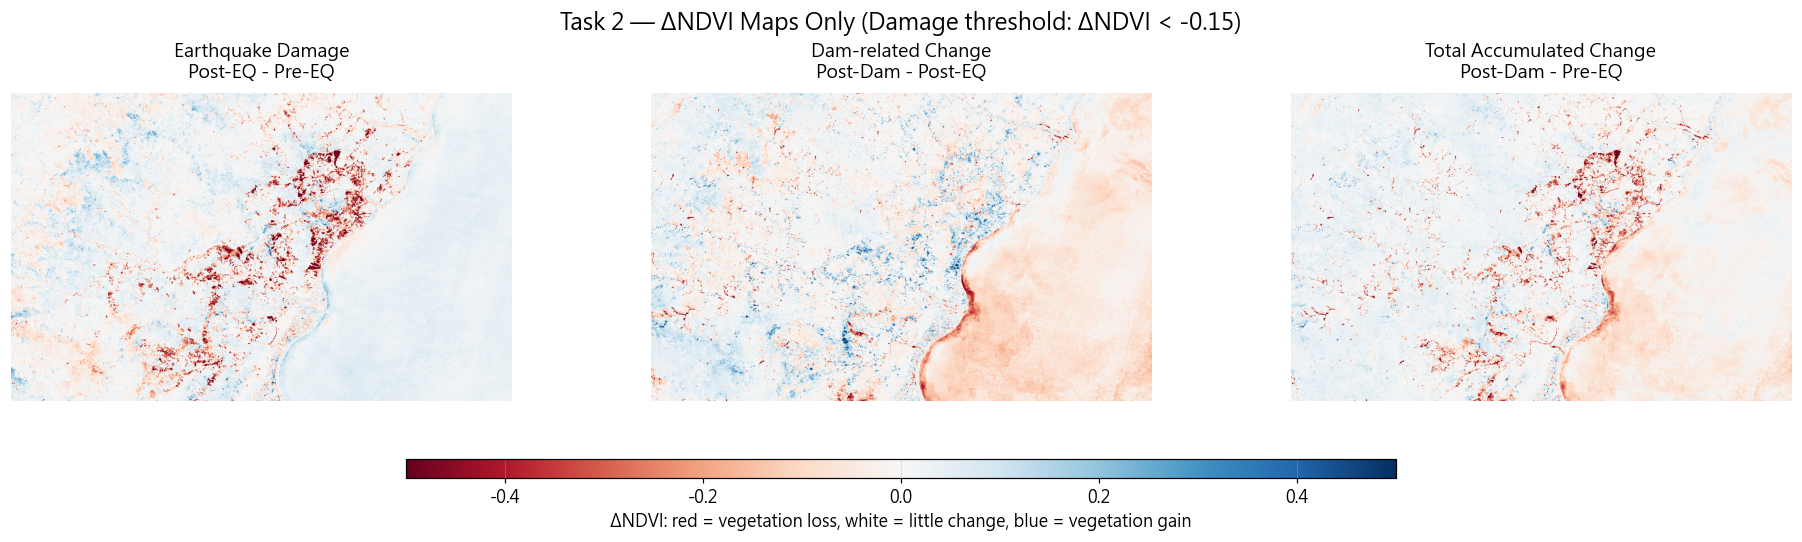


Saved static Task 2 map:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task2_delta_ndvi_static_maps_red_blue.png

✓ Cell 9 completed successfully.
This version uses only one red-white-blue ΔNDVI color scale.

Map interpretation:
  Red   = vegetation loss / NDVI decrease
  White = little or no change
  Blue  = vegetation gain / NDVI increase

Damage area is still calculated using:
  ΔNDVI < -0.15


In [18]:
# ============================================================================
# Task 2 — Pre/Post Earthquake Median Composite
# Cell 9 — Calculate Damaged Area and Display Static ΔNDVI Maps
# ============================================================================

DAMAGE_THRESHOLD = -0.15


# ----------------------------------------------------------------------------
# 1. Define area calculation function
# ----------------------------------------------------------------------------

def calculate_damage_area_ha(delta_image, band_name, label, threshold=-0.15):
    """
    Calculate area where delta NDVI is lower than the threshold.
    """

    damage_mask = (
        delta_image
        .select(band_name)
        .lt(threshold)
        .selfMask()
    )

    damage_area_m2 = (
        damage_mask
        .multiply(ee.Image.pixelArea())
        .rename("damage_area_m2")
    )

    area_stats = (
        damage_area_m2
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=10,
            maxPixels=1e10
        )
        .getInfo()
    )

    area_m2 = area_stats.get("damage_area_m2", 0)

    if area_m2 is None:
        area_m2 = 0

    area_ha = area_m2 / 10000
    area_km2 = area_m2 / 1_000_000

    print(label)
    print("--------------------------------------------------")
    print(f"Threshold       : ΔNDVI < {threshold}")
    print(f"Damage area     : {area_ha:.2f} ha")
    print(f"Damage area     : {area_km2:.4f} km²")
    print("")

    return {
        "phase": label,
        "threshold": threshold,
        "damage_area_m2": area_m2,
        "damage_area_ha": area_ha,
        "damage_area_km2": area_km2
    }


# ----------------------------------------------------------------------------
# 2. Calculate damage area for three ΔNDVI layers
# ----------------------------------------------------------------------------

damage_eq = calculate_damage_area_ha(
    delta_image=delta_eq_vis,
    band_name="delta_NDVI_eq",
    label="Earthquake damage: Post-EQ − Pre-EQ",
    threshold=DAMAGE_THRESHOLD
)

damage_dam = calculate_damage_area_ha(
    delta_image=delta_dam_vis,
    band_name="delta_NDVI_dam",
    label="Dam-related change: Post-Dam − Post-EQ",
    threshold=DAMAGE_THRESHOLD
)

damage_total = calculate_damage_area_ha(
    delta_image=delta_total_vis,
    band_name="delta_NDVI_total",
    label="Total accumulated change: Post-Dam − Pre-EQ",
    threshold=DAMAGE_THRESHOLD
)


# ----------------------------------------------------------------------------
# 3. Save summary table
# ----------------------------------------------------------------------------

task2_damage_area_df = pd.DataFrame([
    damage_eq,
    damage_dam,
    damage_total
])

print("Task 2 — ΔNDVI damage area summary")
display(task2_damage_area_df)

task2_damage_csv = OUTPUT_DIR / "task2_delta_ndvi_damage_area.csv"

task2_damage_area_df.to_csv(
    task2_damage_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Task 2 damage area CSV:")
print(task2_damage_csv)


# ----------------------------------------------------------------------------
# 4. Convert GEE images to numpy arrays
# ----------------------------------------------------------------------------

VIS_SCALE = 60

def ee_image_to_array(image, band_name, region, scale=60):
    """
    Convert a single-band ee.Image to a 2D numpy array.
    """

    arr = geemap.ee_to_numpy(
        image.select(band_name),
        region=region,
        scale=scale
    )

    if arr is None:
        raise ValueError(f"Failed to convert {band_name} to numpy array.")

    arr = np.squeeze(arr).astype(float)

    return arr


print("\nConverting GEE layers to numpy arrays for static plotting...")
print("This may take 1–3 minutes.")

delta_eq_arr = ee_image_to_array(
    delta_eq_vis,
    "delta_NDVI_eq",
    aoi,
    scale=VIS_SCALE
)

delta_dam_arr = ee_image_to_array(
    delta_dam_vis,
    "delta_NDVI_dam",
    aoi,
    scale=VIS_SCALE
)

delta_total_arr = ee_image_to_array(
    delta_total_vis,
    "delta_NDVI_total",
    aoi,
    scale=VIS_SCALE
)

print("✓ Conversion completed.")


# ----------------------------------------------------------------------------
# 5. Clean arrays
# ----------------------------------------------------------------------------

def clean_delta_array(arr):
    arr = np.where(np.isfinite(arr), arr, np.nan)
    return arr

delta_eq_arr = clean_delta_array(delta_eq_arr)
delta_dam_arr = clean_delta_array(delta_dam_arr)
delta_total_arr = clean_delta_array(delta_total_arr)


# ----------------------------------------------------------------------------
# 6. Plot three static ΔNDVI maps
# ----------------------------------------------------------------------------
# Only one color scale is used:
# Red   = NDVI decrease / vegetation loss
# White = little change
# Blue  = NDVI increase / vegetation gain

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

maps = [
    {
        "title": "Earthquake Damage\nPost-EQ - Pre-EQ",
        "delta": delta_eq_arr
    },
    {
        "title": "Dam-related Change\nPost-Dam - Post-EQ",
        "delta": delta_dam_arr
    },
    {
        "title": "Total Accumulated Change\nPost-Dam - Pre-EQ",
        "delta": delta_total_arr
    }
]

for ax, item in zip(axes, maps):

    im = ax.imshow(
        item["delta"],
        cmap="RdBu",
        vmin=-0.5,
        vmax=0.5
    )

    ax.set_title(
        item["title"],
        fontsize=12,
        pad=10
    )

    ax.axis("off")


# ----------------------------------------------------------------------------
# 7. Move colorbar to bottom blank area
# ----------------------------------------------------------------------------

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.80,
    bottom=0.24,
    wspace=0.10
)

cbar_ax = fig.add_axes(
    [0.25, 0.10, 0.50, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label(
    "ΔNDVI: red = vegetation loss, white = little change, blue = vegetation gain",
    fontsize=11
)

fig.suptitle(
    f"Task 2 — ΔNDVI Maps Only (Damage threshold: ΔNDVI < {DAMAGE_THRESHOLD})",
    fontsize=15,
    y=0.95
)


# ----------------------------------------------------------------------------
# 8. Save static map figure
# ----------------------------------------------------------------------------

task2_static_map_path = OUTPUT_DIR / "task2_delta_ndvi_static_maps_red_blue.png"

plt.savefig(
    task2_static_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved static Task 2 map:")
print(task2_static_map_path)


# ----------------------------------------------------------------------------
# 9. Print interpretation
# ----------------------------------------------------------------------------

print("\n✓ Cell 9 completed successfully.")
print("This version uses only one red-white-blue ΔNDVI color scale.")
print("")
print("Map interpretation:")
print("  Red   = vegetation loss / NDVI decrease")
print("  White = little or no change")
print("  Blue  = vegetation gain / NDVI increase")
print("")
print("Damage area is still calculated using:")
print(f"  ΔNDVI < {DAMAGE_THRESHOLD}")

# Task 2 — Written Analysis and W9/W13 Comparison

This cell generates the written analysis for Task 2.  
It summarizes the three ΔNDVI change stages, compares damaged areas, and explains why W13 composite-based change detection is more robust than W9 two-scene change detection.

In [19]:
# ============================================================================
# Task 2 — Pre/Post Earthquake Median Composite
# Cell 10 — Written Analysis and W9 / W13 Comparison
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Extract damage area values from Task 2 table
# ----------------------------------------------------------------------------

eq_area_ha = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Earthquake damage: Post-EQ − Pre-EQ",
    "damage_area_ha"
].values[0]

dam_area_ha = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Dam-related change: Post-Dam − Post-EQ",
    "damage_area_ha"
].values[0]

total_area_ha = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Total accumulated change: Post-Dam − Pre-EQ",
    "damage_area_ha"
].values[0]

eq_area_km2 = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Earthquake damage: Post-EQ − Pre-EQ",
    "damage_area_km2"
].values[0]

dam_area_km2 = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Dam-related change: Post-Dam − Post-EQ",
    "damage_area_km2"
].values[0]

total_area_km2 = task2_damage_area_df.loc[
    task2_damage_area_df["phase"] == "Total accumulated change: Post-Dam − Pre-EQ",
    "damage_area_km2"
].values[0]


# ----------------------------------------------------------------------------
# 2. Generate Task 2 written analysis
# ----------------------------------------------------------------------------

task2_analysis_md = f"""# Task 2 — Pre/Post Earthquake Median Composite Analysis

## 1. Three-phase ΔNDVI damage area summary

Using the threshold **ΔNDVI < {DAMAGE_THRESHOLD}**, the estimated vegetation-loss areas are:

| Change stage | Meaning | Damage area (ha) | Damage area (km²) |
|---|---|---:|---:|
| Post-EQ − Pre-EQ | Earthquake-related vegetation loss | {eq_area_ha:.2f} | {eq_area_km2:.4f} |
| Post-Dam − Post-EQ | Post-dam or later-stage change | {dam_area_ha:.2f} | {dam_area_km2:.4f} |
| Post-Dam − Pre-EQ | Total accumulated change | {total_area_ha:.2f} | {total_area_km2:.4f} |

## 2. Interpretation

The **Post-EQ − Pre-EQ** ΔNDVI map shows the immediate vegetation decrease after the 2024 Hualien earthquake.  
The estimated damaged area is **{eq_area_ha:.2f} ha**, suggesting that a considerable portion of the Xiulin / Taroko study area experienced NDVI decline after the earthquake.

The **Post-Dam − Post-EQ** map represents later-stage change after the post-earthquake period.  
Its damaged area is **{dam_area_ha:.2f} ha**, indicating that some areas continued to show NDVI decline during the later period.  
However, this stage should be interpreted carefully because the change may include effects from later disturbances, seasonal differences, vegetation recovery patterns, or cloud-mask-related compositing differences.

The **Post-Dam − Pre-EQ** map represents the total accumulated difference between the later period and the pre-earthquake baseline.  
The estimated accumulated damaged area is **{total_area_ha:.2f} ha**, which helps evaluate whether the landscape remained below the pre-earthquake NDVI condition.

## 3. W9 two-scene change detection vs. W13 composite-based change detection

In Week 9, change detection relied mainly on two individual Sentinel-2 scenes.  
That approach is sensitive to cloud cover, cloud shadow, atmospheric differences, seasonal mismatch, and scene-specific noise.  
In contrast, Week 13 uses Google Earth Engine to build **median composites** from many images within each phase.  
This reduces the influence of individual cloudy or noisy scenes and produces a more stable representation of each period.

The three-phase W13 design is also more informative than a simple before-after comparison.  
Instead of only detecting total change, it separates the timeline into earthquake-related change, post-dam or later-stage change, and total accumulated change.  
Therefore, the W13 method is more suitable for disaster monitoring because it turns a snapshot-based comparison into a multi-stage temporal interpretation.

## 4. 中文說明

本任務使用 **ΔNDVI < {DAMAGE_THRESHOLD}** 作為植被明顯下降的判斷門檻。  
結果顯示，地震後相對震前的植被損失面積約為 **{eq_area_ha:.2f} ha**；堰塞湖後相對震後的下降面積約為 **{dam_area_ha:.2f} ha**；堰塞湖後相對震前的累積下降面積約為 **{total_area_ha:.2f} ha**。

W9 的方法主要是兩張單景影像相減，因此容易受到雲、雲影、季節差異與單張影像品質影響。  
W13 則利用 GEE 將多張影像做 median composite，可降低單景雜訊與雲遮罩造成的不穩定性。  
此外，三期比較能將地震直接影響、後續變化與累積影響分開討論，因此更適合用於災害監測與長期環境變遷分析。
"""

print(task2_analysis_md)


# ----------------------------------------------------------------------------
# 3. Save Task 2 analysis to output folder
# ----------------------------------------------------------------------------

task2_analysis_path = OUTPUT_DIR / "task2_delta_ndvi_analysis.md"

with open(task2_analysis_path, "w", encoding="utf-8") as f:
    f.write(task2_analysis_md)

print("\nSaved Task 2 analysis Markdown:")
print(task2_analysis_path)


# ----------------------------------------------------------------------------
# 4. Task 2 completion checklist
# ----------------------------------------------------------------------------

print("\nTask 2 completion checklist")
print("--------------------------------------------------")
print("✓ Three-phase NDVI median composites created")
print("✓ Three ΔNDVI maps generated")
print("✓ ΔNDVI static map saved")
print("✓ Damage area calculated for three phases")
print("✓ W9 vs W13 comparison written")
print("✓ Task 2 analysis saved")

print("\n✓ Cell 10 completed successfully.")

# Task 2 — Pre/Post Earthquake Median Composite Analysis

## 1. Three-phase ΔNDVI damage area summary

Using the threshold **ΔNDVI < -0.15**, the estimated vegetation-loss areas are:

| Change stage | Meaning | Damage area (ha) | Damage area (km²) |
|---|---|---:|---:|
| Post-EQ − Pre-EQ | Earthquake-related vegetation loss | 7740.15 | 77.4015 |
| Post-Dam − Post-EQ | Post-dam or later-stage change | 6257.68 | 62.5768 |
| Post-Dam − Pre-EQ | Total accumulated change | 6839.04 | 68.3904 |

## 2. Interpretation

The **Post-EQ − Pre-EQ** ΔNDVI map shows the immediate vegetation decrease after the 2024 Hualien earthquake.  
The estimated damaged area is **7740.15 ha**, suggesting that a considerable portion of the Xiulin / Taroko study area experienced NDVI decline after the earthquake.

The **Post-Dam − Post-EQ** map represents later-stage change after the post-earthquake period.  
Its damaged area is **6257.68 ha**, indicating that some areas continued to show NDVI decline during the lat

# Task 3 — Sentinel-1 SAR Time Series
## Cell 11 — Filter Sentinel-1 GRD VV ImageCollection

This cell filters Sentinel-1 GRD imagery over the Xiulin / Taroko AOI.  
It keeps IW-mode, descending-pass, VV-polarized images from 2022-01-01 to 2026-03-31.  
The resulting `s1_vv` ImageCollection will be used for SAR VV time-series analysis and pre/post-earthquake ΔVV mapping.

In [20]:
# ============================================================================
# Task 3 — Sentinel-1 SAR Time Series
# Cell 11 — Filter Sentinel-1 GRD VV ImageCollection
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Filter Sentinel-1 GRD ImageCollection
# ----------------------------------------------------------------------------
# Dataset:
# COPERNICUS/S1_GRD
#
# Homework requirement:
# - AOI: Xiulin / Taroko
# - Date range: 2022-01-01 to 2026-03-31
# - instrumentMode: IW
# - orbitProperties_pass: DESCENDING
# - polarization: VV
# - select VV band

s1_vv = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(S1_START, S1_END)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .select("VV")
)

s1_count = s1_vv.size().getInfo()

print("Task 3 — Sentinel-1 GRD VV ImageCollection")
print("--------------------------------------------------")
print(f"Study area        : Xiulin / Taroko")
print(f"Date range        : {S1_START} to {S1_END}")
print(f"Instrument mode   : IW")
print(f"Orbit pass        : DESCENDING")
print(f"Polarization      : VV")
print(f"Total S1 images   : {s1_count}")


# ----------------------------------------------------------------------------
# 2. Inspect first Sentinel-1 image
# ----------------------------------------------------------------------------

first_s1 = ee.Image(s1_vv.first())

first_s1_date = (
    ee.Date(first_s1.get("system:time_start"))
    .format("YYYY-MM-dd")
    .getInfo()
)

first_s1_bands = first_s1.bandNames().getInfo()

print("\nFirst available S1 image")
print("--------------------------------------------------")
print(f"Date       : {first_s1_date}")
print(f"Band names : {first_s1_bands}")


# ----------------------------------------------------------------------------
# 3. Convert Sentinel-1 metadata to local table
# ----------------------------------------------------------------------------

s1_times = s1_vv.aggregate_array("system:time_start").getInfo()

s1_meta_df = pd.DataFrame({
    "time_start": s1_times
})

s1_meta_df["date"] = pd.to_datetime(
    s1_meta_df["time_start"],
    unit="ms"
)

s1_meta_df["year"] = s1_meta_df["date"].dt.year
s1_meta_df["month"] = s1_meta_df["date"].dt.month
s1_meta_df["year_month"] = s1_meta_df["date"].dt.to_period("M").astype(str)

s1_meta_df = s1_meta_df[
    ["date", "year", "month", "year_month"]
].sort_values("date").reset_index(drop=True)

print("\nSentinel-1 metadata preview:")
display(s1_meta_df.head())


# ----------------------------------------------------------------------------
# 4. Monthly image count summary
# ----------------------------------------------------------------------------

s1_monthly_count = (
    s1_meta_df
    .groupby("year_month")
    .size()
    .reset_index(name="image_count")
)

print("\nSentinel-1 monthly image count preview:")
display(s1_monthly_count.head(12))


# ----------------------------------------------------------------------------
# 5. Save metadata and monthly count to output folder
# ----------------------------------------------------------------------------

s1_meta_csv = OUTPUT_DIR / "task3_sentinel1_metadata.csv"
s1_monthly_csv = OUTPUT_DIR / "task3_sentinel1_monthly_image_count.csv"

s1_meta_df.to_csv(
    s1_meta_csv,
    index=False,
    encoding="utf-8-sig"
)

s1_monthly_count.to_csv(
    s1_monthly_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Sentinel-1 metadata CSV:")
print(s1_meta_csv)

print("\nSaved Sentinel-1 monthly count CSV:")
print(s1_monthly_csv)


# ----------------------------------------------------------------------------
# 6. Quick VV statistics test for first image
# ----------------------------------------------------------------------------
# Sentinel-1 VV values in GEE are already in dB for COPERNICUS/S1_GRD.
# Typical values:
# - Water / smooth surface: lower backscatter
# - Urban / rough surface / exposed terrain: higher backscatter

first_s1_stats = (
    first_s1
    .reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(
                reducer2=ee.Reducer.minMax(),
                sharedInputs=True
            )
        ),
        geometry=aoi,
        scale=100,
        maxPixels=1e8
    )
    .getInfo()
)

print("\nQuick VV statistics for first S1 image")
print("--------------------------------------------------")
print(first_s1_stats)

print("\n✓ Cell 11 completed successfully.")

Task 3 — Sentinel-1 GRD VV ImageCollection
--------------------------------------------------
Study area        : Xiulin / Taroko
Date range        : 2022-01-01 to 2026-03-31
Instrument mode   : IW
Orbit pass        : DESCENDING
Polarization      : VV
Total S1 images   : 146

First available S1 image
--------------------------------------------------
Date       : 2022-01-03
Band names : ['VV']

Sentinel-1 metadata preview:


,date,year,month,year_month
0,2022-01-03 21:52:27,2022,1,2022-01
1,2022-02-08 21:52:26,2022,2,2022-02
2,2022-07-26 21:52:27,2022,7,2022-07
3,2022-08-07 21:52:28,2022,8,2022-08
4,2022-08-19 21:52:29,2022,8,2022-08



Sentinel-1 monthly image count preview:


,year_month,image_count
0,2022-01,1
1,2022-02,1
2,2022-07,1
3,2022-08,3
4,2022-09,2
5,2022-10,3
6,2022-11,2
7,2022-12,3
8,2023-01,2
9,2023-02,3



Saved Sentinel-1 metadata CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_sentinel1_metadata.csv

Saved Sentinel-1 monthly count CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_sentinel1_monthly_image_count.csv

Quick VV statistics for first S1 image
--------------------------------------------------
{'VV_max': 12.628318103562982, 'VV_mean': -9.494771042415893, 'VV_min': -26.059233437803435}

✓ Cell 11 completed successfully.


# Task 3 — Sentinel-1 SAR Time Series
## Cell 12 — Build and Plot VV Time Series

This cell computes mean Sentinel-1 VV backscatter over the Xiulin / Taroko AOI for each image.  
It converts the GEE ImageCollection into a local pandas table, plots the VV time series, marks the 2024 Hualien earthquake, and saves both CSV and PNG outputs.

Extracting mean VV values from Sentinel-1 images...
This may take a few minutes.

Sentinel-1 VV time series preview:


,date,time_start,vv_mean,year,month,year_month
0,2022-01-03,1641246747000,-9.494771,2022,1,2022-01
1,2022-02-08,1644357146000,-9.639472,2022,2,2022-02
2,2022-07-26,1658872347000,-10.767713,2022,7,2022-07
3,2022-08-07,1659909148000,-9.428480,2022,8,2022-08
4,2022-08-19,1660945949000,-10.266628,2022,8,2022-08



VV descriptive statistics:


count    146.000000
mean      -9.433254
std        0.802454
min      -11.364968
25%       -9.939759
50%       -9.480875
75%       -8.947676
max       -7.419990
Name: vv_mean, dtype: float64


Saved Sentinel-1 VV time series CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_sentinel1_vv_timeseries.csv


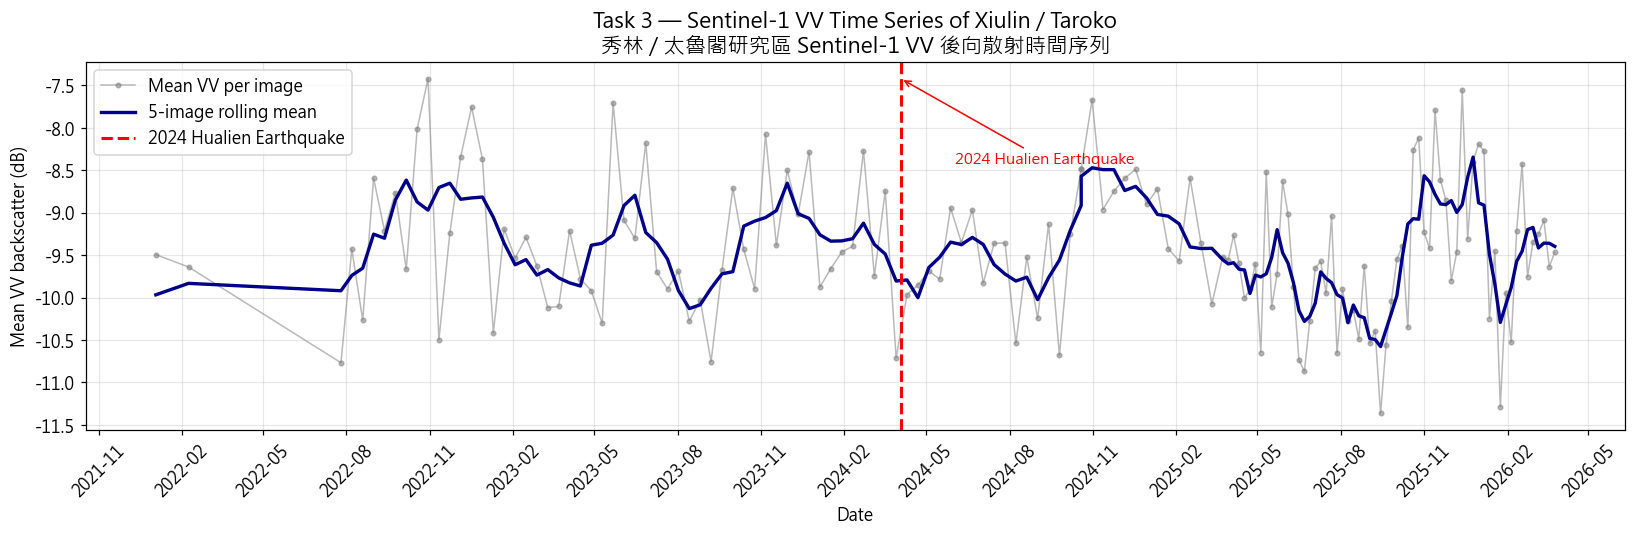


Saved Sentinel-1 VV time series figure:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_sentinel1_vv_timeseries.png

Task 3 quick VV summary
--------------------------------------------------
Mean VV before earthquake : -9.3416 dB
Mean VV after earthquake  : -9.4871 dB
VV change after earthquake: -0.1455 dB

✓ Cell 12 completed successfully.


In [21]:
# ============================================================================
# Task 3 — Sentinel-1 SAR Time Series
# Cell 12 — Build and Plot VV Time Series
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define function to extract mean VV for each Sentinel-1 image
# ----------------------------------------------------------------------------

def extract_mean_vv(image):
    """
    Calculate mean VV backscatter over AOI for a single Sentinel-1 image.
    """

    vv_mean = (
        image
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=100,
            maxPixels=1e8
        )
        .get("VV")
    )

    return ee.Feature(
        None,
        {
            "date": ee.Date(image.get("system:time_start")).format("YYYY-MM-dd"),
            "time_start": image.get("system:time_start"),
            "vv_mean": vv_mean
        }
    )


# ----------------------------------------------------------------------------
# 2. Apply extraction function to ImageCollection
# ----------------------------------------------------------------------------

print("Extracting mean VV values from Sentinel-1 images...")
print("This may take a few minutes.")

vv_fc = ee.FeatureCollection(
    s1_vv.map(extract_mean_vv)
)

vv_features = vv_fc.getInfo()["features"]

vv_records = []

for feature in vv_features:
    props = feature["properties"]

    vv_records.append({
        "date": props.get("date"),
        "time_start": props.get("time_start"),
        "vv_mean": props.get("vv_mean")
    })

task3_vv_df = pd.DataFrame(vv_records)

task3_vv_df["date"] = pd.to_datetime(task3_vv_df["date"])
task3_vv_df["year"] = task3_vv_df["date"].dt.year
task3_vv_df["month"] = task3_vv_df["date"].dt.month
task3_vv_df["year_month"] = task3_vv_df["date"].dt.to_period("M").astype(str)

task3_vv_df = (
    task3_vv_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nSentinel-1 VV time series preview:")
display(task3_vv_df.head())

print("\nVV descriptive statistics:")
display(task3_vv_df["vv_mean"].describe())


# ----------------------------------------------------------------------------
# 3. Save VV time series table
# ----------------------------------------------------------------------------

task3_vv_csv = OUTPUT_DIR / "task3_sentinel1_vv_timeseries.csv"

task3_vv_df.to_csv(
    task3_vv_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Sentinel-1 VV time series CSV:")
print(task3_vv_csv)


# ----------------------------------------------------------------------------
# 4. Add rolling mean for smoother trend
# ----------------------------------------------------------------------------

task3_vv_df["vv_rolling_mean"] = (
    task3_vv_df["vv_mean"]
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
)


# ----------------------------------------------------------------------------
# 5. Plot VV time series
# ----------------------------------------------------------------------------

eq_date = pd.Timestamp(EARTHQUAKE_DATE)

fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.plot(
    task3_vv_df["date"],
    task3_vv_df["vv_mean"],
    marker="o",
    markersize=3,
    linewidth=1,
    alpha=0.55,
    color="gray",
    label="Mean VV per image"
)

ax.plot(
    task3_vv_df["date"],
    task3_vv_df["vv_rolling_mean"],
    linewidth=2.2,
    color="darkblue",
    label="5-image rolling mean"
)

ax.axvline(
    eq_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label=EARTHQUAKE_LABEL
)

ax.annotate(
    EARTHQUAKE_LABEL,
    xy=(eq_date, task3_vv_df["vv_mean"].max()),
    xytext=(eq_date + pd.Timedelta(days=60), task3_vv_df["vv_mean"].max() - 1),
    color="red",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)

ax.set_title(
    "Task 3 — Sentinel-1 VV Time Series of Xiulin / Taroko\n"
    "秀林 / 太魯閣研究區 Sentinel-1 VV 後向散射時間序列",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Mean VV backscatter (dB)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)
plt.tight_layout()


# ----------------------------------------------------------------------------
# 6. Save figure
# ----------------------------------------------------------------------------

task3_vv_plot_path = OUTPUT_DIR / "task3_sentinel1_vv_timeseries.png"

plt.savefig(
    task3_vv_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved Sentinel-1 VV time series figure:")
print(task3_vv_plot_path)


# ----------------------------------------------------------------------------
# 7. Quick pre/post earthquake VV comparison
# ----------------------------------------------------------------------------

pre_eq_vv_mean = task3_vv_df[
    task3_vv_df["date"] < eq_date
]["vv_mean"].mean()

post_eq_vv_mean = task3_vv_df[
    task3_vv_df["date"] >= eq_date
]["vv_mean"].mean()

vv_change = post_eq_vv_mean - pre_eq_vv_mean

print("\nTask 3 quick VV summary")
print("--------------------------------------------------")
print(f"Mean VV before earthquake : {pre_eq_vv_mean:.4f} dB")
print(f"Mean VV after earthquake  : {post_eq_vv_mean:.4f} dB")
print(f"VV change after earthquake: {vv_change:+.4f} dB")

print("\n✓ Cell 12 completed successfully.")

# Task 3 — Sentinel-1 SAR Time Series
## Cell 13 — Build Pre/Post VV Composites and ΔVV Map

This cell creates pre-earthquake and post-earthquake Sentinel-1 VV median composites.  
It then calculates ΔVV as post-earthquake VV minus pre-earthquake VV.  
The resulting ΔVV map is used to detect surface backscatter changes and will later be compared with ΔNDVI damage areas.

Task 3 — Pre/Post VV composites created
--------------------------------------------------
Pre-EQ VV period  : 2023-01-01 to 2024-03-31
Post-EQ VV period : 2024-04-01 to 2026-03-31

ΔVV layer created
--------------------------------------------------
delta_vv = post_vv - pre_vv

Images used in VV composites:


,phase,period,image_count
0,pre_eq_vv,2023-01-01 to 2024-03-31,38
1,post_eq_vv,2024-04-01 to 2026-03-31,92


Pre-EQ VV statistics
--------------------------------------------------
{'pre_VV_max': 11.04199318576159, 'pre_VV_mean': -9.416746694329294, 'pre_VV_min': -24.29098705768429}

Post-EQ VV statistics
--------------------------------------------------
{'post_VV_max': 9.43806019805755, 'post_VV_mean': -9.422689815666818, 'post_VV_min': -24.896224744645927}

ΔVV statistics
--------------------------------------------------
{'delta_VV_max': 10.512277307263364, 'delta_VV_mean': -0.00594312133777587, 'delta_VV_min': -6.509227731172815}

Task 3 — VV composite and ΔVV statistics summary


,layer,mean,min,max
0,pre_VV,-9.416747,-24.290987,11.041993
1,post_VV,-9.422690,-24.896225,9.438060
2,delta_VV,-0.005943,-6.509228,10.512277



Saved VV composite image-count CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_vv_composite_image_counts.csv

Saved ΔVV statistics CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_delta_vv_stats.csv

Converting ΔVV to numpy array for static plotting...


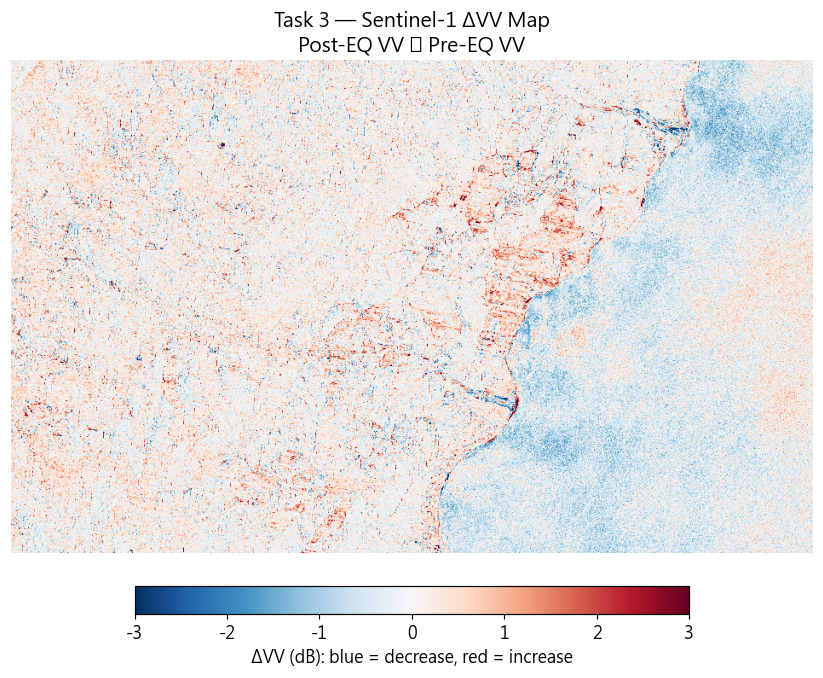


Saved ΔVV map:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_delta_vv_map.png

✓ Cell 13 completed successfully.


In [22]:
# ============================================================================
# Task 3 — Sentinel-1 SAR Time Series
# Cell 13 — Build Pre/Post VV Composites and ΔVV Map
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Build pre-earthquake and post-earthquake VV median composites
# ----------------------------------------------------------------------------
# Homework requirement:
# pre_vv  = 2023-01-01 to 2024-03-31
# post_vv = 2024-04-01 to 2026-03-31
#
# Sentinel-1 VV values are in dB in COPERNICUS/S1_GRD.

pre_vv = (
    s1_vv
    .filterDate(PRE_EQ_START, PRE_EQ_END)
    .median()
    .rename("pre_VV")
    .clip(aoi)
)

post_vv = (
    s1_vv
    .filterDate(POST_EQ_START, S1_END)
    .median()
    .rename("post_VV")
    .clip(aoi)
)

print("Task 3 — Pre/Post VV composites created")
print("--------------------------------------------------")
print(f"Pre-EQ VV period  : {PRE_EQ_START} to {PRE_EQ_END}")
print(f"Post-EQ VV period : {POST_EQ_START} to {S1_END}")


# ----------------------------------------------------------------------------
# 2. Calculate ΔVV
# ----------------------------------------------------------------------------
# Important:
# Since pre_vv and post_vv have different band names,
# rename both to "VV" before subtraction to avoid band-name mismatch.

pre_vv_std = pre_vv.rename("VV")
post_vv_std = post_vv.rename("VV")

delta_vv = (
    post_vv_std
    .subtract(pre_vv_std)
    .rename("delta_VV")
    .clip(aoi)
)

print("\nΔVV layer created")
print("--------------------------------------------------")
print("delta_vv = post_vv - pre_vv")


# ----------------------------------------------------------------------------
# 3. Count images used in each VV composite
# ----------------------------------------------------------------------------

pre_vv_count = (
    s1_vv
    .filterDate(PRE_EQ_START, PRE_EQ_END)
    .size()
    .getInfo()
)

post_vv_count = (
    s1_vv
    .filterDate(POST_EQ_START, S1_END)
    .size()
    .getInfo()
)

task3_vv_count_df = pd.DataFrame({
    "phase": [
        "pre_eq_vv",
        "post_eq_vv"
    ],
    "period": [
        f"{PRE_EQ_START} to {PRE_EQ_END}",
        f"{POST_EQ_START} to {S1_END}"
    ],
    "image_count": [
        pre_vv_count,
        post_vv_count
    ]
})

print("\nImages used in VV composites:")
display(task3_vv_count_df)


# ----------------------------------------------------------------------------
# 4. Calculate statistics for pre_vv, post_vv, and delta_vv
# ----------------------------------------------------------------------------

def sar_stats_over_aoi(image, band_name, label, region=aoi, scale=100):
    """
    Calculate mean, min, and max over AOI for a SAR image band.
    """

    stats = (
        image
        .select(band_name)
        .reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(
                    reducer2=ee.Reducer.minMax(),
                    sharedInputs=True
                )
            ),
            geometry=region,
            scale=scale,
            maxPixels=1e8
        )
        .getInfo()
    )

    print(label)
    print("--------------------------------------------------")
    print(stats)
    print("")

    return stats


stats_pre_vv = sar_stats_over_aoi(
    pre_vv,
    "pre_VV",
    "Pre-EQ VV statistics"
)

stats_post_vv = sar_stats_over_aoi(
    post_vv,
    "post_VV",
    "Post-EQ VV statistics"
)

stats_delta_vv = sar_stats_over_aoi(
    delta_vv,
    "delta_VV",
    "ΔVV statistics"
)


task3_delta_vv_stats_df = pd.DataFrame([
    {
        "layer": "pre_VV",
        "mean": stats_pre_vv.get("pre_VV_mean"),
        "min": stats_pre_vv.get("pre_VV_min"),
        "max": stats_pre_vv.get("pre_VV_max")
    },
    {
        "layer": "post_VV",
        "mean": stats_post_vv.get("post_VV_mean"),
        "min": stats_post_vv.get("post_VV_min"),
        "max": stats_post_vv.get("post_VV_max")
    },
    {
        "layer": "delta_VV",
        "mean": stats_delta_vv.get("delta_VV_mean"),
        "min": stats_delta_vv.get("delta_VV_min"),
        "max": stats_delta_vv.get("delta_VV_max")
    }
])

print("Task 3 — VV composite and ΔVV statistics summary")
display(task3_delta_vv_stats_df)


# ----------------------------------------------------------------------------
# 5. Save statistics and image-count summaries
# ----------------------------------------------------------------------------

task3_vv_count_csv = OUTPUT_DIR / "task3_vv_composite_image_counts.csv"
task3_delta_vv_stats_csv = OUTPUT_DIR / "task3_delta_vv_stats.csv"

task3_vv_count_df.to_csv(
    task3_vv_count_csv,
    index=False,
    encoding="utf-8-sig"
)

task3_delta_vv_stats_df.to_csv(
    task3_delta_vv_stats_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved VV composite image-count CSV:")
print(task3_vv_count_csv)

print("\nSaved ΔVV statistics CSV:")
print(task3_delta_vv_stats_csv)


# ----------------------------------------------------------------------------
# 6. Static ΔVV map
# ----------------------------------------------------------------------------
# Use numpy + matplotlib for stable display, same strategy as Task 2.

print("\nConverting ΔVV to numpy array for static plotting...")

delta_vv_arr = geemap.ee_to_numpy(
    delta_vv.select("delta_VV"),
    region=aoi,
    scale=60
)

delta_vv_arr = np.squeeze(delta_vv_arr).astype(float)
delta_vv_arr = np.where(np.isfinite(delta_vv_arr), delta_vv_arr, np.nan)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

im = ax.imshow(
    delta_vv_arr,
    cmap="RdBu_r",
    vmin=-3,
    vmax=3
)

ax.set_title(
    "Task 3 — Sentinel-1 ΔVV Map\nPost-EQ VV − Pre-EQ VV",
    fontsize=13
)

ax.axis("off")

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    fraction=0.05,
    pad=0.06
)

cbar.set_label(
    "ΔVV (dB): blue = decrease, red = increase"
)

plt.tight_layout()

task3_delta_vv_map_path = OUTPUT_DIR / "task3_delta_vv_map.png"

plt.savefig(
    task3_delta_vv_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved ΔVV map:")
print(task3_delta_vv_map_path)

print("\n✓ Cell 13 completed successfully.")

# Task 3 — Sentinel-1 SAR Time Series
## Cell 14 — Cross-reference ΔNDVI and ΔVV

This cell identifies high-confidence change areas by combining optical and SAR evidence.  
A pixel is classified as high-confidence change when ΔNDVI < -0.15 and |ΔVV| > 2 dB.  
The result is summarized as area statistics and visualized as a static map.

Task 3 — High-confidence change area
--------------------------------------------------
Condition 1: ΔNDVI < -0.15
Condition 2: |ΔVV| > 2.0 dB
Area       : 537.37 ha
Area       : 5.3737 km²

Saved high-confidence change summary CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_ndvi_sar_high_confidence_change.csv

Converting NDVI, VV, and high-confidence layers to numpy arrays...
This may take 1–3 minutes.
✓ Conversion completed.


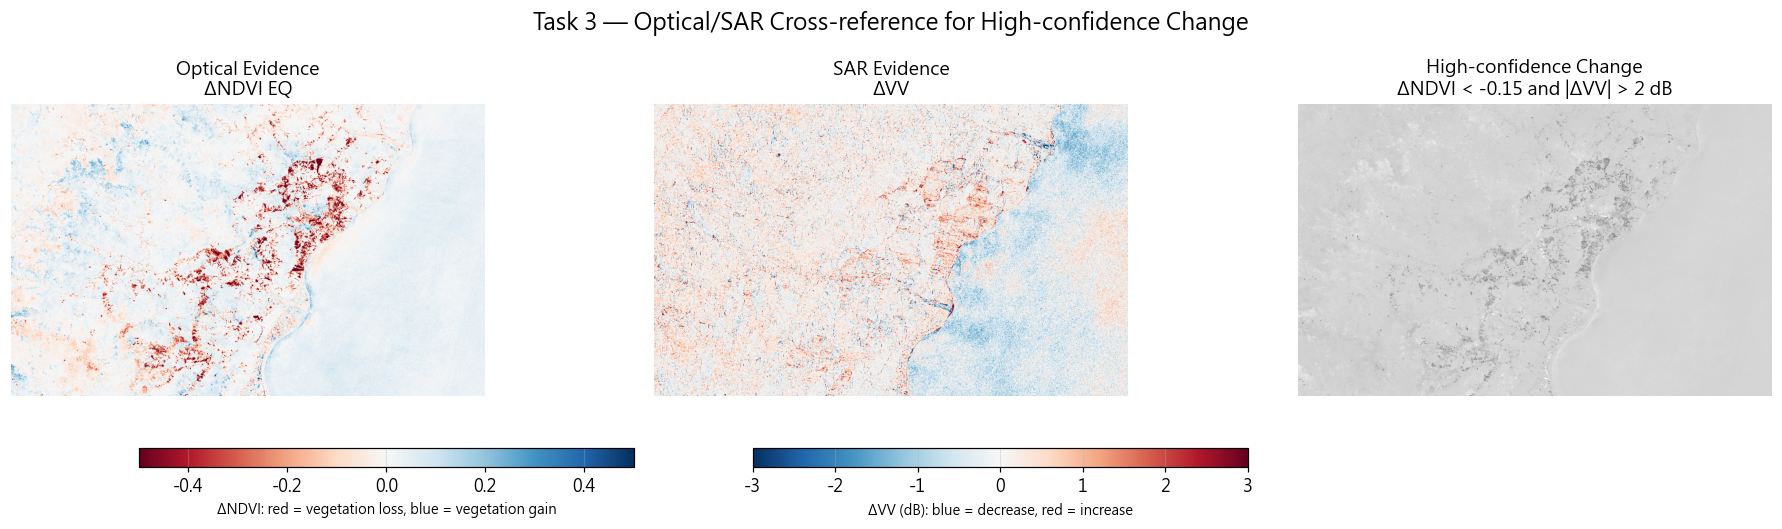


Saved NDVI/SAR cross-reference map:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task3_ndvi_sar_high_confidence_change_map.png

✓ Cell 14 completed successfully.
High-confidence change is defined as:
  ΔNDVI < -0.15
  AND |ΔVV| > 2.0 dB

Interpretation:
  These areas show both vegetation loss and SAR backscatter change.
  They are more reliable candidates for disaster-related surface change.


In [23]:
# ============================================================================
# Task 3 — Sentinel-1 SAR Time Series
# Cell 14 — Cross-reference ΔNDVI and ΔVV
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define thresholds
# ----------------------------------------------------------------------------

NDVI_DAMAGE_THRESHOLD = -0.15
VV_CHANGE_THRESHOLD = 2.0


# ----------------------------------------------------------------------------
# 2. Build high-confidence change mask
# ----------------------------------------------------------------------------
# Optical condition:
#   ΔNDVI < -0.15
#
# SAR condition:
#   |ΔVV| > 2 dB
#
# High-confidence change:
#   both conditions are true

ndvi_damage_mask = (
    delta_eq_vis
    .select("delta_NDVI_eq")
    .lt(NDVI_DAMAGE_THRESHOLD)
)

sar_change_mask = (
    delta_vv
    .select("delta_VV")
    .abs()
    .gt(VV_CHANGE_THRESHOLD)
)

high_confidence_change = (
    ndvi_damage_mask
    .And(sar_change_mask)
    .selfMask()
    .rename("high_confidence_change")
)


# ----------------------------------------------------------------------------
# 3. Calculate high-confidence change area
# ----------------------------------------------------------------------------

high_conf_area_m2_img = (
    high_confidence_change
    .multiply(ee.Image.pixelArea())
    .rename("high_conf_area_m2")
)

high_conf_area_stats = (
    high_conf_area_m2_img
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e10
    )
    .getInfo()
)

high_conf_area_m2 = high_conf_area_stats.get("high_conf_area_m2", 0)

if high_conf_area_m2 is None:
    high_conf_area_m2 = 0

high_conf_area_ha = high_conf_area_m2 / 10000
high_conf_area_km2 = high_conf_area_m2 / 1_000_000

print("Task 3 — High-confidence change area")
print("--------------------------------------------------")
print(f"Condition 1: ΔNDVI < {NDVI_DAMAGE_THRESHOLD}")
print(f"Condition 2: |ΔVV| > {VV_CHANGE_THRESHOLD} dB")
print(f"Area       : {high_conf_area_ha:.2f} ha")
print(f"Area       : {high_conf_area_km2:.4f} km²")


# ----------------------------------------------------------------------------
# 4. Save cross-reference summary table
# ----------------------------------------------------------------------------

task3_cross_ref_df = pd.DataFrame([
    {
        "condition": "NDVI damage",
        "definition": f"delta_NDVI_eq < {NDVI_DAMAGE_THRESHOLD}",
        "threshold": NDVI_DAMAGE_THRESHOLD
    },
    {
        "condition": "SAR change",
        "definition": f"abs(delta_VV) > {VV_CHANGE_THRESHOLD} dB",
        "threshold": VV_CHANGE_THRESHOLD
    },
    {
        "condition": "High-confidence change",
        "definition": (
            f"delta_NDVI_eq < {NDVI_DAMAGE_THRESHOLD} "
            f"AND abs(delta_VV) > {VV_CHANGE_THRESHOLD} dB"
        ),
        "area_m2": high_conf_area_m2,
        "area_ha": high_conf_area_ha,
        "area_km2": high_conf_area_km2
    }
])

task3_cross_ref_csv = OUTPUT_DIR / "task3_ndvi_sar_high_confidence_change.csv"

task3_cross_ref_df.to_csv(
    task3_cross_ref_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved high-confidence change summary CSV:")
print(task3_cross_ref_csv)


# ----------------------------------------------------------------------------
# 5. Convert layers to numpy arrays for stable static visualization
# ----------------------------------------------------------------------------

VIS_SCALE = 60

print("\nConverting NDVI, VV, and high-confidence layers to numpy arrays...")
print("This may take 1–3 minutes.")

delta_ndvi_arr = geemap.ee_to_numpy(
    delta_eq_vis.select("delta_NDVI_eq"),
    region=aoi,
    scale=VIS_SCALE
)

delta_vv_arr = geemap.ee_to_numpy(
    delta_vv.select("delta_VV"),
    region=aoi,
    scale=VIS_SCALE
)

high_conf_arr = geemap.ee_to_numpy(
    high_confidence_change,
    region=aoi,
    scale=VIS_SCALE
)

delta_ndvi_arr = np.squeeze(delta_ndvi_arr).astype(float)
delta_vv_arr = np.squeeze(delta_vv_arr).astype(float)
high_conf_arr = np.squeeze(high_conf_arr).astype(float)

delta_ndvi_arr = np.where(np.isfinite(delta_ndvi_arr), delta_ndvi_arr, np.nan)
delta_vv_arr = np.where(np.isfinite(delta_vv_arr), delta_vv_arr, np.nan)
high_conf_arr = np.where(high_conf_arr > 0, 1, np.nan)

print("✓ Conversion completed.")


# ----------------------------------------------------------------------------
# 6. Plot cross-reference maps
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Panel 1: ΔNDVI
im1 = axes[0].imshow(
    delta_ndvi_arr,
    cmap="RdBu",
    vmin=-0.5,
    vmax=0.5
)

axes[0].set_title(
    "Optical Evidence\nΔNDVI EQ",
    fontsize=12
)

axes[0].axis("off")


# Panel 2: ΔVV
im2 = axes[1].imshow(
    delta_vv_arr,
    cmap="RdBu_r",
    vmin=-3,
    vmax=3
)

axes[1].set_title(
    "SAR Evidence\nΔVV",
    fontsize=12
)

axes[1].axis("off")


# Panel 3: High-confidence change
axes[2].imshow(
    delta_ndvi_arr,
    cmap="gray",
    vmin=-0.5,
    vmax=0.5,
    alpha=0.35
)

axes[2].imshow(
    high_conf_arr,
    cmap="Reds",
    alpha=0.9
)

axes[2].set_title(
    "High-confidence Change\nΔNDVI < -0.15 and |ΔVV| > 2 dB",
    fontsize=12
)

axes[2].axis("off")


# ----------------------------------------------------------------------------
# 7. Layout and colorbars
# ----------------------------------------------------------------------------

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.78,
    bottom=0.25,
    wspace=0.12
)

cbar_ax1 = fig.add_axes([0.12, 0.12, 0.25, 0.035])
cbar1 = fig.colorbar(
    im1,
    cax=cbar_ax1,
    orientation="horizontal"
)

cbar1.set_label(
    "ΔNDVI: red = vegetation loss, blue = vegetation gain",
    fontsize=9
)

cbar_ax2 = fig.add_axes([0.43, 0.12, 0.25, 0.035])
cbar2 = fig.colorbar(
    im2,
    cax=cbar_ax2,
    orientation="horizontal"
)

cbar2.set_label(
    "ΔVV (dB): blue = decrease, red = increase",
    fontsize=9
)

fig.suptitle(
    "Task 3 — Optical/SAR Cross-reference for High-confidence Change",
    fontsize=15,
    y=0.95
)


# ----------------------------------------------------------------------------
# 8. Save figure
# ----------------------------------------------------------------------------

task3_cross_ref_map_path = OUTPUT_DIR / "task3_ndvi_sar_high_confidence_change_map.png"

plt.savefig(
    task3_cross_ref_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved NDVI/SAR cross-reference map:")
print(task3_cross_ref_map_path)


# ----------------------------------------------------------------------------
# 9. Print interpretation
# ----------------------------------------------------------------------------

print("\n✓ Cell 14 completed successfully.")
print("High-confidence change is defined as:")
print(f"  ΔNDVI < {NDVI_DAMAGE_THRESHOLD}")
print(f"  AND |ΔVV| > {VV_CHANGE_THRESHOLD} dB")
print("")
print("Interpretation:")
print("  These areas show both vegetation loss and SAR backscatter change.")
print("  They are more reliable candidates for disaster-related surface change.")

# Task 3 — SAR Written Analysis

This cell summarizes the Sentinel-1 SAR results.  
It explains the VV time-series pattern, ΔVV change map, and the high-confidence change area derived from combining ΔNDVI and ΔVV.  
The analysis is saved as a Markdown file in the `output/` folder.

In [28]:
# ============================================================================
# Task 3 — Sentinel-1 SAR Time Series
# Cell 15 — Written Analysis for SAR and NDVI/SAR Cross-reference
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Extract key values from previous cells
# ----------------------------------------------------------------------------

s1_total_images = s1_count

vv_before = pre_eq_vv_mean
vv_after = post_eq_vv_mean
vv_diff = vv_change

delta_vv_mean = task3_delta_vv_stats_df.loc[
    task3_delta_vv_stats_df["layer"] == "delta_VV",
    "mean"
].values[0]

delta_vv_min = task3_delta_vv_stats_df.loc[
    task3_delta_vv_stats_df["layer"] == "delta_VV",
    "min"
].values[0]

delta_vv_max = task3_delta_vv_stats_df.loc[
    task3_delta_vv_stats_df["layer"] == "delta_VV",
    "max"
].values[0]

print("Task 3 key values")
print("--------------------------------------------------")
print(f"Total Sentinel-1 images         : {s1_total_images}")
print(f"Mean VV before earthquake       : {vv_before:.4f} dB")
print(f"Mean VV after earthquake        : {vv_after:.4f} dB")
print(f"Mean VV change                  : {vv_diff:+.4f} dB")
print(f"Mean ΔVV from composite map     : {delta_vv_mean:.4f} dB")
print(f"Min ΔVV                         : {delta_vv_min:.4f} dB")
print(f"Max ΔVV                         : {delta_vv_max:.4f} dB")
print(f"High-confidence change area     : {high_conf_area_ha:.2f} ha")
print(f"High-confidence change area     : {high_conf_area_km2:.4f} km²")


# ----------------------------------------------------------------------------
# 2. Generate written analysis
# ----------------------------------------------------------------------------

task3_analysis_md = f"""
# Task 3 — Sentinel-1 SAR Time Series Analysis

## 1. Sentinel-1 VV time series

This task used **{s1_total_images} Sentinel-1 GRD VV images** from **{S1_START} to {S1_END}** over the Xiulin / Taroko study area.  
The mean VV backscatter before the 2024 Hualien earthquake was **{vv_before:.4f} dB**, while the mean VV after the earthquake was **{vv_after:.4f} dB**.  
The overall post-earthquake change was therefore **{vv_diff:+.4f} dB**, suggesting that the AOI-wide average SAR backscatter changed only slightly after the earthquake.

## 2. ΔVV map interpretation

The ΔVV map was calculated as:

```text
ΔVV = Post-EQ VV − Pre-EQ VV
The mean ΔVV from the composite map was {delta_vv_mean:.4f} dB, with values ranging from {delta_vv_min:.4f} dB to {delta_vv_max:.4f} dB.
Positive ΔVV values may indicate increased surface roughness, exposed soil, landslide scars, or stronger radar scattering.
Negative ΔVV values may indicate smoother surfaces, moisture changes, geometric effects, or reduced backscatter.

## 3. NDVI/SAR cross-reference

To identify high-confidence change areas, this task combined optical and SAR evidence:
ΔNDVI < {NDVI_DAMAGE_THRESHOLD}
AND
|ΔVV| > {VV_CHANGE_THRESHOLD} dB
The resulting high-confidence change area was {high_conf_area_ha:.2f} ha ({high_conf_area_km2:.4f} km²).
These areas are more reliable candidates for disaster-related surface change because they show both vegetation loss in Sentinel-2 NDVI and significant backscatter change in Sentinel-1 SAR.

4. 中文說明

本任務使用 {s1_total_images} 張 Sentinel-1 GRD VV 影像，分析秀林 / 太魯閣研究區在 2022–2026 年間的 SAR 後向散射變化。
地震前平均 VV 約為 {vv_before:.4f} dB，地震後平均 VV 約為 {vv_after:.4f} dB，整體變化為 {vv_diff:+.4f} dB。
這代表若只看整個 AOI 的平均 SAR 訊號，地震後變化並不劇烈，但空間上的 ΔVV map 仍可顯示局部地表散射變化。

透過交叉比對 ΔNDVI < {NDVI_DAMAGE_THRESHOLD} 與 |ΔVV| > {VV_CHANGE_THRESHOLD} dB，可找出同時具有植被下降與 SAR 散射變化的高信度變化區。
本次估計的高信度變化面積為 {high_conf_area_ha:.2f} ha，顯示多源資料結合能比單獨使用 NDVI 或 SAR 更有助於篩選可能的災害變化區。
"""


print(task3_analysis_md)

#----------------------------------------------------------------------------
# 3. Save Task 3 analysis to output folder
#----------------------------------------------------------------------------

task3_analysis_path = OUTPUT_DIR / "task3_sentinel1_sar_analysis.md"

with open(task3_analysis_path, "w", encoding="utf-8") as f:
    f.write(task3_analysis_md)

print("\nSaved Task 3 analysis Markdown:")
print(task3_analysis_path)

#----------------------------------------------------------------------------
#4. Task 3 completion checklist
#----------------------------------------------------------------------------

print("\nTask 3 completion checklist")
print("--------------------------------------------------")
print("✓ Sentinel-1 GRD VV ImageCollection filtered")
print("✓ VV time series table generated")
print("✓ VV time series plot saved")
print("✓ Pre/Post VV composites created")
print("✓ ΔVV map generated and saved")
print("✓ NDVI/SAR high-confidence change area calculated")
print("✓ NDVI/SAR cross-reference map saved")
print("✓ SAR analysis written and saved")

print("\n✓ Cell 15 completed successfully.")


Task 3 key values
--------------------------------------------------
Total Sentinel-1 images         : 146
Mean VV before earthquake       : -9.3416 dB
Mean VV after earthquake        : -9.4871 dB
Mean VV change                  : -0.1455 dB
Mean ΔVV from composite map     : -0.0059 dB
Min ΔVV                         : -6.5092 dB
Max ΔVV                         : 10.5123 dB
High-confidence change area     : 537.37 ha
High-confidence change area     : 5.3737 km²

# Task 3 — Sentinel-1 SAR Time Series Analysis

## 1. Sentinel-1 VV time series

This task used **146 Sentinel-1 GRD VV images** from **2022-01-01 to 2026-03-31** over the Xiulin / Taroko study area.  
The mean VV backscatter before the 2024 Hualien earthquake was **-9.3416 dB**, while the mean VV after the earthquake was **-9.4871 dB**.  
The overall post-earthquake change was therefore **-0.1455 dB**, suggesting that the AOI-wide average SAR backscatter changed only slightly after the earthquake.

## 2. ΔVV map interpretation

# Task 4 — Export GeoTIFF
## Cell 16 — Export NDVI Composite and ΔNDVI Maps to Google Drive

This cell exports key GEE products as GeoTIFF files to Google Drive.  
The required outputs are the post-earthquake NDVI composite and the ΔNDVI map.  
An additional total ΔNDVI map is exported for integration and reporting.

In [29]:
# ============================================================================
# Task 4 — Export GeoTIFF + Integration Summary
# Cell 16 — Export NDVI Composite and ΔNDVI Maps to Google Drive
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define export parameters
# ----------------------------------------------------------------------------
# Homework requirement:
# Export at least two products:
# 1. Post-earthquake NDVI composite
# 2. ΔNDVI map
#
# Projection:
# EPSG:32651 = UTM Zone 51N, suitable for eastern Taiwan.
#
# Scale:
# 10 m = Sentinel-2 native resolution for B4 / B8 NDVI.

EXPORT_FOLDER = "GEE_Exports"
EXPORT_SCALE = 10
EXPORT_CRS = "EPSG:32651"


# ----------------------------------------------------------------------------
# 2. Prepare export images
# ----------------------------------------------------------------------------
# Use standardized band names for clean GeoTIFF outputs.

export_post_eq_ndvi = (
    post_eq_ndvi_vis
    .rename("post_eq_NDVI")
    .toFloat()
    .clip(aoi)
)

export_delta_eq = (
    delta_eq_vis
    .rename("delta_NDVI_eq")
    .toFloat()
    .clip(aoi)
)

export_delta_total = (
    delta_total_vis
    .rename("delta_NDVI_total")
    .toFloat()
    .clip(aoi)
)


# ----------------------------------------------------------------------------
# 3. Create Google Drive export tasks
# ----------------------------------------------------------------------------

task_post_eq_ndvi = ee.batch.Export.image.toDrive(
    image=export_post_eq_ndvi,
    description="taroko_post_eq_ndvi_2024",
    folder=EXPORT_FOLDER,
    fileNamePrefix="taroko_post_eq_ndvi_2024",
    region=aoi,
    scale=EXPORT_SCALE,
    crs=EXPORT_CRS,
    maxPixels=1e10
)

task_delta_eq = ee.batch.Export.image.toDrive(
    image=export_delta_eq,
    description="taroko_delta_ndvi_eq_2024",
    folder=EXPORT_FOLDER,
    fileNamePrefix="taroko_delta_ndvi_eq_2024",
    region=aoi,
    scale=EXPORT_SCALE,
    crs=EXPORT_CRS,
    maxPixels=1e10
)

task_delta_total = ee.batch.Export.image.toDrive(
    image=export_delta_total,
    description="taroko_delta_ndvi_total_2026",
    folder=EXPORT_FOLDER,
    fileNamePrefix="taroko_delta_ndvi_total_2026",
    region=aoi,
    scale=EXPORT_SCALE,
    crs=EXPORT_CRS,
    maxPixels=1e10
)


# ----------------------------------------------------------------------------
# 4. Start export tasks
# ----------------------------------------------------------------------------
# Note:
# GEE export is asynchronous.
# task.start() only submits the job; it does not mean the file is ready.
# Check Google Drive > GEE_Exports after the tasks finish.

task_post_eq_ndvi.start()
task_delta_eq.start()
task_delta_total.start()

print("Task 4 — GeoTIFF exports started")
print("--------------------------------------------------")
print(f"Google Drive folder : {EXPORT_FOLDER}")
print(f"Scale               : {EXPORT_SCALE} m")
print(f"CRS                 : {EXPORT_CRS}")
print("")
print("Started export tasks:")
print("1. taroko_post_eq_ndvi_2024.tif")
print("2. taroko_delta_ndvi_eq_2024.tif")
print("3. taroko_delta_ndvi_total_2026.tif")


# ----------------------------------------------------------------------------
# 5. Display task status
# ----------------------------------------------------------------------------

print("\nTask status:")
print("--------------------------------------------------")
print("Post-EQ NDVI:")
print(task_post_eq_ndvi.status())

print("\nΔNDVI EQ:")
print(task_delta_eq.status())

print("\nΔNDVI Total:")
print(task_delta_total.status())


# ----------------------------------------------------------------------------
# 6. Save local export log to output folder
# ----------------------------------------------------------------------------

export_log_df = pd.DataFrame([
    {
        "product": "post_eq_ndvi",
        "description": "taroko_post_eq_ndvi_2024",
        "file_name": "taroko_post_eq_ndvi_2024.tif",
        "drive_folder": EXPORT_FOLDER,
        "scale_m": EXPORT_SCALE,
        "crs": EXPORT_CRS
    },
    {
        "product": "delta_ndvi_eq",
        "description": "taroko_delta_ndvi_eq_2024",
        "file_name": "taroko_delta_ndvi_eq_2024.tif",
        "drive_folder": EXPORT_FOLDER,
        "scale_m": EXPORT_SCALE,
        "crs": EXPORT_CRS
    },
    {
        "product": "delta_ndvi_total",
        "description": "taroko_delta_ndvi_total_2026",
        "file_name": "taroko_delta_ndvi_total_2026.tif",
        "drive_folder": EXPORT_FOLDER,
        "scale_m": EXPORT_SCALE,
        "crs": EXPORT_CRS
    }
])

export_log_csv = OUTPUT_DIR / "task4_export_log.csv"

export_log_df.to_csv(
    export_log_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved export log:")
print(export_log_csv)


print("\n✓ Cell 16 completed successfully.")
print("Next step: check Google Drive > GEE_Exports and take a screenshot after export finishes.")

Task 4 — GeoTIFF exports started
--------------------------------------------------
Google Drive folder : GEE_Exports
Scale               : 10 m
CRS                 : EPSG:32651

Started export tasks:
1. taroko_post_eq_ndvi_2024.tif
2. taroko_delta_ndvi_eq_2024.tif
3. taroko_delta_ndvi_total_2026.tif

Task status:
--------------------------------------------------
Post-EQ NDVI:
{'state': 'READY', 'description': 'taroko_post_eq_ndvi_2024', 'priority': 100, 'creation_timestamp_ms': 1779542962279, 'update_timestamp_ms': 1779542962279, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'OYHMAEZP226YPIHEOHGOVDC4', 'name': 'projects/rsga-496805/operations/OYHMAEZP226YPIHEOHGOVDC4'}

ΔNDVI EQ:
{'state': 'READY', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779542962667, 'update_timestamp_ms': 1779542962667, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '24L6HTBOQ2NJSA4ZWMJDVXWA', 'name': 'projects/rsga-496805/operations/24L6HTBO

# Task 4 — Export Status Check
## Cell 17 — Check Google Earth Engine Export Task Status

This cell checks the status of the three GeoTIFF export tasks submitted in Cell 16.  
If the task state is `READY` or `RUNNING`, wait and run this cell again later.  
When the state becomes `COMPLETED`, check Google Drive > GEE_Exports and take a screenshot for submission.

In [30]:
# ============================================================================
# Task 4 — Export GeoTIFF + Integration Summary
# Cell 17 — Check Google Earth Engine Export Task Status
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Check current status of export tasks
# ----------------------------------------------------------------------------

export_tasks = [
    {
        "product": "Post-EQ NDVI composite",
        "expected_file": "taroko_post_eq_ndvi_2024.tif",
        "task": task_post_eq_ndvi
    },
    {
        "product": "Earthquake ΔNDVI map",
        "expected_file": "taroko_delta_ndvi_eq_2024.tif",
        "task": task_delta_eq
    },
    {
        "product": "Total ΔNDVI map",
        "expected_file": "taroko_delta_ndvi_total_2026.tif",
        "task": task_delta_total
    }
]

task_status_records = []

print("Task 4 — GEE Export Task Status")
print("==================================================")

for item in export_tasks:

    status = item["task"].status()

    state = status.get("state", "UNKNOWN")
    description = status.get("description", "")
    task_id = status.get("id", "")
    error_message = status.get("error_message", "")

    print(item["product"])
    print("--------------------------------------------------")
    print(f"Expected file : {item['expected_file']}")
    print(f"Description   : {description}")
    print(f"State         : {state}")
    print(f"Task ID       : {task_id}")

    if error_message:
        print(f"Error message : {error_message}")

    print("")

    task_status_records.append({
        "product": item["product"],
        "expected_file": item["expected_file"],
        "description": description,
        "state": state,
        "task_id": task_id,
        "error_message": error_message
    })


# ----------------------------------------------------------------------------
# 2. Save task status table
# ----------------------------------------------------------------------------

task4_status_df = pd.DataFrame(task_status_records)

task4_status_csv = OUTPUT_DIR / "task4_export_status.csv"

task4_status_df.to_csv(
    task4_status_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Saved export status CSV:")
print(task4_status_csv)

display(task4_status_df)


# ----------------------------------------------------------------------------
# 3. Guidance message
# ----------------------------------------------------------------------------

completed_count = (task4_status_df["state"] == "COMPLETED").sum()
total_count = len(task4_status_df)

print("\nExport progress summary")
print("--------------------------------------------------")
print(f"Completed tasks: {completed_count} / {total_count}")

if completed_count == total_count:
    print("✓ All exports completed.")
    print("Next step: open Google Drive > GEE_Exports and take a screenshot of the exported GeoTIFF files.")
else:
    print("Some tasks are not completed yet.")
    print("If state is READY: the task is waiting in the queue.")
    print("If state is RUNNING: the task is currently exporting.")
    print("Run this cell again later until all tasks are COMPLETED.")

print("\n✓ Cell 17 completed successfully.")

Task 4 — GEE Export Task Status
Post-EQ NDVI composite
--------------------------------------------------
Expected file : taroko_post_eq_ndvi_2024.tif
Description   : taroko_post_eq_ndvi_2024
State         : COMPLETED
Task ID       : OYHMAEZP226YPIHEOHGOVDC4

Earthquake ΔNDVI map
--------------------------------------------------
Expected file : taroko_delta_ndvi_eq_2024.tif
Description   : taroko_delta_ndvi_eq_2024
State         : COMPLETED
Task ID       : 24L6HTBOQ2NJSA4ZWMJDVXWA

Total ΔNDVI map
--------------------------------------------------
Expected file : taroko_delta_ndvi_total_2026.tif
Description   : taroko_delta_ndvi_total_2026
State         : COMPLETED
Task ID       : SNKWAI6V4P34PWX2MP34QHBJ

Saved export status CSV:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\task4_export_status.csv


,product,expected_file,description,state,task_id,error_message
0,Post-EQ NDVI composite,taroko_post_eq_ndvi_2024.tif,taroko_post_eq_ndvi_2024,COMPLETED,OYHMAEZP226YPIHEOHGOVDC4,
1,Earthquake ΔNDVI map,taroko_delta_ndvi_eq_2024.tif,taroko_delta_ndvi_eq_2024,COMPLETED,24L6HTBOQ2NJSA4ZWMJDVXWA,
2,Total ΔNDVI map,taroko_delta_ndvi_total_2026.tif,taroko_delta_ndvi_total_2026,COMPLETED,SNKWAI6V4P34PWX2MP34QHBJ,



Export progress summary
--------------------------------------------------
Completed tasks: 3 / 3
✓ All exports completed.
Next step: open Google Drive > GEE_Exports and take a screenshot of the exported GeoTIFF files.

✓ Cell 17 completed successfully.


於Google Drive 儲存的GeoTIFF檔

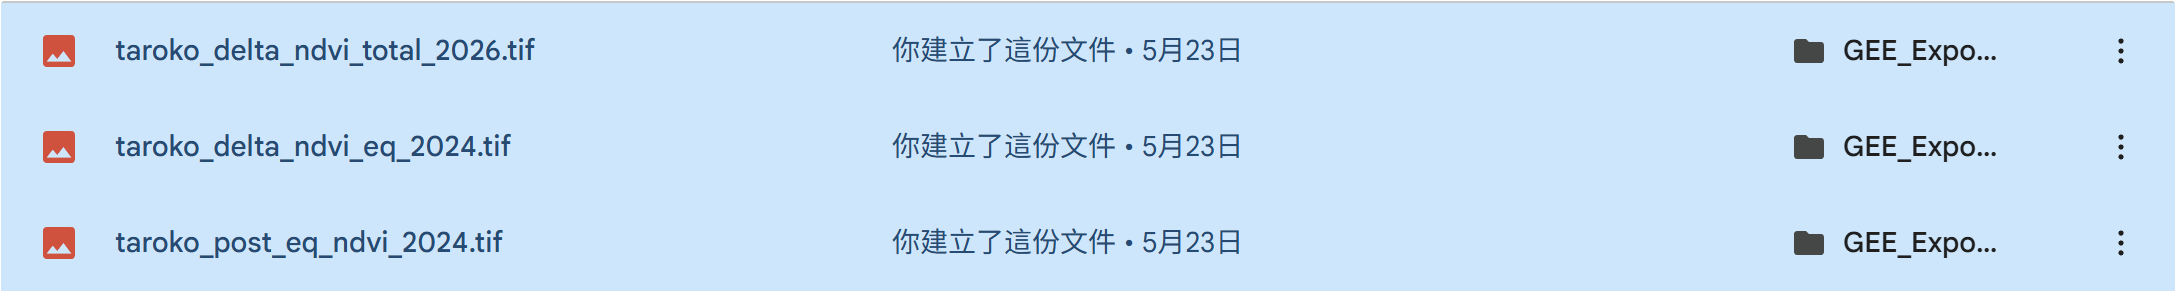

# Task 4 — Integration Summary Report
## Cell 18 — Generate 300–500 Word Integration Summary

This cell generates the Task 4 integration summary report.  
It summarizes data scale, key findings, cross-week integration, and limitations of the ARIA v9.0 cloud workflow.  
The report is saved as a Markdown file in the `output/` folder.

In [32]:
# ============================================================================
# Task 4 — Export GeoTIFF + Integration Summary
# Cell 18 — Generate Integration Summary Report
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Collect key numbers from previous tasks
# ----------------------------------------------------------------------------

sentinel2_count = s2_count
sentinel1_count = s1_count

# Rough local download estimate
# Assumptions:
# - One Sentinel-2 L2A image ≈ 800 MB
# - One Sentinel-1 GRD image ≈ 700 MB
# - Download speed ≈ 50 Mbps = 6.25 MB/s
# These are rough estimates for discussion, not exact file sizes.

s2_size_mb = sentinel2_count * 800
s1_size_mb = sentinel1_count * 700
total_size_mb = s2_size_mb + s1_size_mb
total_size_gb = total_size_mb / 1024

download_speed_mb_s = 6.25
download_time_seconds = total_size_mb / download_speed_mb_s
download_time_hours = download_time_seconds / 3600

# Key NDVI values from Task 1
task4_pre_eq_ndvi = pre_eq_mean
task4_post_eq_ndvi = post_eq_mean
task4_post_dam_ndvi = post_dam_mean

# Key ΔNDVI areas from Task 2
task4_eq_area_ha = eq_area_ha
task4_dam_area_ha = dam_area_ha
task4_total_area_ha = total_area_ha

# Key SAR values from Task 3
task4_vv_before = vv_before
task4_vv_after = vv_after
task4_vv_diff = vv_diff

task4_delta_vv_mean = delta_vv_mean
task4_high_conf_area_ha = high_conf_area_ha
task4_high_conf_area_km2 = high_conf_area_km2


# ----------------------------------------------------------------------------
# 2. Generate structured 300–500 word integration summary
# ----------------------------------------------------------------------------

task4_summary_md = f"""# Task 4 — Integration Summary Report

## a. Data scale comparison

This Week 13 workflow processed **{sentinel2_count} Sentinel-2 images** and **{sentinel1_count} Sentinel-1 images** over the Xiulin / Taroko study area.  
If these datasets were downloaded and processed locally, the estimated data volume would be approximately **{total_size_gb:.1f} GB**, assuming about 800 MB per Sentinel-2 image and 700 MB per Sentinel-1 GRD image.  
At an approximate download speed of 50 Mbps, downloading alone could take around **{download_time_hours:.1f} hours**, before considering local storage, preprocessing, cloud masking, compositing, and raster calculation time.  
Using Google Earth Engine avoids this bottleneck because filtering, compositing, NDVI calculation, SAR processing, and export are executed on Google’s cloud servers.

## b. Key findings

The monthly NDVI time series showed temporal variability across 2020–2026.  
The mean NDVI before the earthquake was **{task4_pre_eq_ndvi:.4f}**, while the post-earthquake mean was **{task4_post_eq_ndvi:.4f}**, indicating that the AOI-wide average NDVI changed only slightly.  
However, the spatial ΔNDVI maps revealed stronger localized vegetation loss.  
Using **ΔNDVI < -0.15**, the estimated vegetation-loss area was **{task4_eq_area_ha:.2f} ha** for the earthquake phase, **{task4_dam_area_ha:.2f} ha** for the post-dam or later-stage phase, and **{task4_total_area_ha:.2f} ha** for total accumulated change.  
The SAR analysis showed that mean VV changed from **{task4_vv_before:.4f} dB** before the earthquake to **{task4_vv_after:.4f} dB** afterward, with a small overall difference of **{task4_vv_diff:+.4f} dB**.  
Although the AOI-wide SAR mean was stable, the ΔVV map captured local backscatter changes.  
By combining **ΔNDVI < -0.15** and **|ΔVV| > 2 dB**, the high-confidence change area was estimated as **{task4_high_conf_area_ha:.2f} ha** (**{task4_high_conf_area_km2:.4f} km²**), suggesting that optical and SAR evidence overlap in selected disturbance zones.

## c. Cross-week integration

Compared with **W8 single-scene NDVI**, the GEE time-series workflow improves interpretation by showing multi-year temporal context instead of one snapshot.  
This helps distinguish event-related change from seasonal vegetation variation and image-specific noise.  
Compared with **W9 two-scene change detection**, median composites are more robust because they combine many images within each phase and reduce the influence of clouds, cloud shadows, and abnormal single-scene conditions.  
Compared with **W10 single-scene SAR**, the GEE SAR workflow extends the analysis into a multi-year VV backscatter time series and allows pre/post-earthquake ΔVV mapping.  
If the exported GeoTIFFs were used in **W12 Random Forest classification**, post-earthquake NDVI, ΔNDVI, and ΔVV could serve as additional predictor layers.  
They would likely help the classifier separate stable vegetation, disturbed slopes, exposed surfaces, and possible landslide-affected areas more effectively than spectral bands alone.

## d. Limitations

GEE is powerful for large-scale preprocessing and time-series analysis, but it is not suitable for every workflow.  
It cannot easily run arbitrary local Python libraries, highly customized machine-learning pipelines, detailed raster editing, or full InSAR processing requiring Sentinel-1 SLC phase data.  
For tasks requiring `rasterio`, `scikit-learn`, custom deep learning, local sample editing, manual QGIS inspection, or non-GEE datasets from external STAC catalogs, the W8–W12 local approach is still preferable.  
Therefore, the best workflow is complementary: use GEE for cloud-scale filtering, compositing, and export, then use local Python or QGIS for customized modeling, validation, visualization, and final interpretation.

## 中文摘要

本週作業共處理 **{sentinel2_count} 張 Sentinel-2 影像**與 **{sentinel1_count} 張 Sentinel-1 影像**。若全部下載到本機，資料量約為 **{total_size_gb:.1f} GB**，以 50 Mbps 網速估計，光下載就可能需要約 **{download_time_hours:.1f} 小時**。GEE 的優勢在於可直接於雲端完成大量影像篩選、雲遮罩、NDVI 計算、SAR 分析與 GeoTIFF 匯出。

結果顯示，整體平均 NDVI 在地震前後變化不大，但 ΔNDVI 空間圖揭示局部植被下降。以 **ΔNDVI < -0.15** 判斷，地震階段植被損失面積約為 **{task4_eq_area_ha:.2f} ha**，後續階段約為 **{task4_dam_area_ha:.2f} ha**，累積變化約為 **{task4_total_area_ha:.2f} ha**。SAR 分析中，平均 VV 變化僅 **{task4_vv_diff:+.4f} dB**，但 ΔVV map 仍能呈現局部散射變化。結合 NDVI 與 SAR 後，高信度變化區約為 **{task4_high_conf_area_ha:.2f} ha**。整體而言，W13 的 GEE 流程能將 W8 的單景 NDVI、W9 的兩期變遷偵測、W10 的 SAR 概念與 W12 的分類資料整合成雲端多時相分析流程。
"""

print(task4_summary_md)


# ----------------------------------------------------------------------------
# 3. Save integration summary to output folder
# ----------------------------------------------------------------------------

task4_summary_path = OUTPUT_DIR / "task4_integration_summary_report.md"

with open(task4_summary_path, "w", encoding="utf-8") as f:
    f.write(task4_summary_md)

print("\nSaved Task 4 integration summary Markdown:")
print(task4_summary_path)


# ----------------------------------------------------------------------------
# 4. Task 4 checklist
# ----------------------------------------------------------------------------

print("\nTask 4 completion checklist")
print("--------------------------------------------------")
print("✓ At least 2 GeoTIFF exports submitted")
print("✓ Export task status checked")
print("✓ Data scale comparison included")
print("✓ Key findings included")
print("✓ Cross-week integration included")
print("✓ Limitations included")
print("✓ Integration summary saved")

print("\n✓ Cell 18 completed successfully.")

# Task 4 — Integration Summary Report

## a. Data scale comparison

This Week 13 workflow processed **291 Sentinel-2 images** and **146 Sentinel-1 images** over the Xiulin / Taroko study area.  
If these datasets were downloaded and processed locally, the estimated data volume would be approximately **327.1 GB**, assuming about 800 MB per Sentinel-2 image and 700 MB per Sentinel-1 GRD image.  
At an approximate download speed of 50 Mbps, downloading alone could take around **14.9 hours**, before considering local storage, preprocessing, cloud masking, compositing, and raster calculation time.  
Using Google Earth Engine avoids this bottleneck because filtering, compositing, NDVI calculation, SAR processing, and export are executed on Google’s cloud servers.

## b. Key findings

The monthly NDVI time series showed temporal variability across 2020–2026.  
The mean NDVI before the earthquake was **0.4851**, while the post-earthquake mean was **0.4815**, indicating that the AOI-wide averag

# Bonus 1 — 2016 熊本地震 InSAR 干涉圖判讀

#### 1. 衛星資訊：該干涉圖使用哪個衛星？什麼波段？波長多少？

> 此干涉圖使用日本 JAXA 的 **ALOS-2（Advanced Land Observing Satellite-2）** 衛星資料進行解算。  
> 使用的是 **L-band（L 波段）合成孔徑雷達（SAR）**，其波長約為 **23.6 公分**。

---

#### 2. 每環位移量：每一個完整干涉環代表多少公分的位移？

> InSAR 的一個完整干涉環（fringe）代表雷達波往返路徑改變 **半個波長（λ/2）**。  
> 已知 L 波段波長為 **23.6 公分**，因此：

\[
\frac{23.6}{2}=11.8\ \text{cm}
\]

> 約可視為 **12 公分／環**。

---

#### 3. 干涉環數量：斷層上方區域大約有幾個完整的干涉環？

> 由圖中斷層上方區域（主要箭頭指示方向附近）觀察，避開近斷層失相干（Loss of Coherence）區域後，由外向內計算可辨識約 **15–17 個完整干涉環**。  
> 此結果也與文章說明一致。

---

#### 4. 位移方向：色階變化是「藍→黃→紫」還是「藍→紫→黃」？代表接近還是遠離衛星？

> 斷層上方區域的干涉環色彩變化主要呈現：

**藍 → 紫 → 黃**

> 根據圖例判讀，此代表地表變形方向為：

**遠離衛星（Away from satellite）**

> 表示沿雷達視線方向（LOS）上，地表朝遠離衛星方向移動，與熊本地震右移斷層活動特徵一致。

---

#### 5. 總位移量估算：根據以上資訊，估算 LOS（視線方向）位移量是多少公分？

已知：

- 每環位移量 ≈ **12 cm**
- 干涉環數量 ≈ **15–17 環**

估算：

\[
15\times12=180\ \text{cm}
\]

\[
17\times12=204\ \text{cm}
\]

因此：

> 此事件的 LOS（Line of Sight）位移量約為：

**180–204 公分（約 1.8–2.0 公尺）**

> 與現地調查指出最大約 **2 公尺地表變形量**相符。

---

#### Bonus Reflection（心得）

相較於 W10 使用的 SAR 振幅分析（Amplitude Analysis），InSAR 不只是觀察地物反射強弱變化，而是利用相位資訊直接量測毫米至公分尺度的地表位移，因此能夠推估地殼移動方向與變形量。SAR 振幅雖然可以辨識淹水、崩塌或地表粗糙度改變，但無法像 InSAR 一樣定量估計地表位移。透過彩虹干涉環，可以更直觀理解地震造成的地殼形變空間分布與累積變位量。

# Bonus 2 — NDVI Time-Lapse Animation
## Cell B1 — Build animation periods and output settings

This cell defines:
- Semi-annual NDVI composite periods
- Output GIF location
- NDVI color palette
- Event labels for annotation

No images are downloaded yet.

In [33]:
# ============================================================================
# Bonus 2 — NDVI Time-Lapse Animation
# Cell B1 — Build animation periods and output settings
# ============================================================================

from pathlib import Path
import io
import requests
import imageio
import numpy as np

from PIL import (
    Image,
    ImageDraw,
    ImageFont
)

# ----------------------------------------------------------------------------
# 1. Define half-year periods
# ----------------------------------------------------------------------------

periods = [

    ("2020-01","2020-06"),
    ("2020-07","2020-12"),

    ("2021-01","2021-06"),
    ("2021-07","2021-12"),

    ("2022-01","2022-06"),
    ("2022-07","2022-12"),

    ("2023-01","2023-06"),
    ("2023-07","2023-12"),

    ("2024-01","2024-03"),   # pre earthquake
    ("2024-04","2024-09"),   # earthquake

    ("2024-10","2025-03"),
    ("2025-04","2025-09"),

    ("2025-10","2026-03")    # dam stage
]

print("Bonus 2 periods")
print("==================================================")

for i, p in enumerate(periods):

    print(
        f"{i+1:02d}. "
        f"{p[0]} → {p[1]}"
    )


# ----------------------------------------------------------------------------
# 2. NDVI visualization
# ----------------------------------------------------------------------------

NDVI_VIS = {

    "min":0,

    "max":0.8,

    "palette":[

        "#8c510a",   # brown
        "#d8b365",   # yellow
        "#5aae61",   # green
        "#1b7837"    # dark green
    ]
}


# ----------------------------------------------------------------------------
# 3. Event labels
# ----------------------------------------------------------------------------

EVENT_LABELS = {

    "2024-04":"★ 2024 Earthquake",

    "2025-10":"★ Post-Dam"
}


# ----------------------------------------------------------------------------
# 4. Output paths
# ----------------------------------------------------------------------------

BONUS_DIR = OUTPUT_DIR / "bonus2"

BONUS_DIR.mkdir(
    exist_ok=True
)

FRAME_DIR = BONUS_DIR / "frames"

FRAME_DIR.mkdir(
    exist_ok=True
)

GIF_PATH = (
    BONUS_DIR
    /
    "taroko_ndvi_timelapse.gif"
)

print("\nOutput folders")
print("--------------------------------------------------")

print(FRAME_DIR)
print(GIF_PATH)


# ----------------------------------------------------------------------------
# 5. Initialize frame list
# ----------------------------------------------------------------------------

frames = []

print("\n✓ Cell B1 completed successfully.")
print("Next: download NDVI thumbnails from GEE.")

Bonus 2 periods
01. 2020-01 → 2020-06
02. 2020-07 → 2020-12
03. 2021-01 → 2021-06
04. 2021-07 → 2021-12
05. 2022-01 → 2022-06
06. 2022-07 → 2022-12
07. 2023-01 → 2023-06
08. 2023-07 → 2023-12
09. 2024-01 → 2024-03
10. 2024-04 → 2024-09
11. 2024-10 → 2025-03
12. 2025-04 → 2025-09
13. 2025-10 → 2026-03

Output folders
--------------------------------------------------
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\bonus2\frames
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\bonus2\taroko_ndvi_timelapse.gif

✓ Cell B1 completed successfully.
Next: download NDVI thumbnails from GEE.


# Bonus 2 — NDVI Time-Lapse Animation
## Cell B2 — Download NDVI thumbnails and annotate frames

This cell creates a median NDVI composite for each semi-annual period.  
It downloads each composite as a thumbnail from GEE, adds period labels and event labels, and saves each frame as a PNG file.

In [34]:
# ============================================================================
# Bonus 2 — NDVI Time-Lapse Animation
# Cell B2 — Download NDVI Thumbnails and Annotate Frames
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define helper functions
# ----------------------------------------------------------------------------

def month_to_date_start(month_text):
    """
    Convert YYYY-MM to YYYY-MM-01.
    """
    return f"{month_text}-01"


def month_to_date_end(month_text):
    """
    Convert YYYY-MM to an approximate safe end date.
    GEE filterDate uses start inclusive and end exclusive.
    Using day 28 avoids invalid dates for February.
    """
    return f"{month_text}-28"


def get_default_font(size=24):
    """
    Try to use a common Windows font.
    Fall back to PIL default font if unavailable.
    """
    possible_fonts = [
        "C:/Windows/Fonts/arial.ttf",
        "C:/Windows/Fonts/calibri.ttf",
        "C:/Windows/Fonts/msjh.ttc"   # Microsoft JhengHei
    ]

    for font_path in possible_fonts:
        if Path(font_path).exists():
            return ImageFont.truetype(font_path, size=size)

    return ImageFont.load_default()


def add_label_to_frame(
    img,
    label,
    event_label=None
):
    """
    Add period label and optional event label to an RGB image.
    """

    img = img.copy().convert("RGB")

    draw = ImageDraw.Draw(img)

    font_title = get_default_font(size=26)
    font_event = get_default_font(size=22)

    # Semi-transparent label box
    box_x0, box_y0 = 15, 15
    box_x1, box_y1 = 430, 92

    overlay = Image.new(
        "RGBA",
        img.size,
        (255, 255, 255, 0)
    )

    overlay_draw = ImageDraw.Draw(overlay)

    overlay_draw.rectangle(
        [box_x0, box_y0, box_x1, box_y1],
        fill=(0, 0, 0, 150)
    )

    img = Image.alpha_composite(
        img.convert("RGBA"),
        overlay
    ).convert("RGB")

    draw = ImageDraw.Draw(img)

    draw.text(
        (30, 26),
        label,
        fill=(255, 255, 255),
        font=font_title
    )

    if event_label is not None:

        draw.text(
            (30, 58),
            event_label,
            fill=(255, 220, 0),
            font=font_event
        )

    return img


# ----------------------------------------------------------------------------
# 2. Download thumbnails from GEE
# ----------------------------------------------------------------------------

frames = []
frame_records = []

DIMENSIONS = 512

print("Downloading NDVI thumbnail frames from GEE...")
print("==================================================")

for idx, (start_month, end_month) in enumerate(periods):

    start_date = month_to_date_start(start_month)
    end_date = month_to_date_end(end_month)

    period_label = f"{start_month} to {end_month}"

    event_label = None

    if start_month in EVENT_LABELS:
        event_label = EVENT_LABELS[start_month]

    # Build median NDVI composite for this period
    period_collection = (
        ndvi_collection
        .filterDate(start_date, end_date)
        .select("NDVI")
    )

    n_images = period_collection.size().getInfo()

    if n_images == 0:
        print(f"{idx+1:02d}. {period_label}: no image, skipped")
        continue

    composite = (
        period_collection
        .median()
        .clip(aoi)
    )

    # Get thumbnail URL
    thumb_url = composite.getThumbURL({
        "region": aoi,
        "dimensions": DIMENSIONS,
        "min": NDVI_VIS["min"],
        "max": NDVI_VIS["max"],
        "palette": NDVI_VIS["palette"],
        "format": "png"
    })

    response = requests.get(thumb_url)

    if response.status_code != 200:
        print(f"{idx+1:02d}. {period_label}: download failed")
        print(response.text[:300])
        continue

    img = Image.open(
        io.BytesIO(response.content)
    ).convert("RGB")

    img = add_label_to_frame(
        img,
        label=period_label,
        event_label=event_label
    )

    frame_path = FRAME_DIR / f"frame_{idx+1:02d}_{start_month}_{end_month}.png"

    img.save(frame_path)

    frames.append(img)

    frame_records.append({
        "frame_id": idx + 1,
        "start_month": start_month,
        "end_month": end_month,
        "start_date": start_date,
        "end_date": end_date,
        "image_count": n_images,
        "event_label": event_label,
        "frame_path": str(frame_path)
    })

    print(
        f"{idx+1:02d}. {period_label}: OK "
        f"(n={n_images}) → {frame_path.name}"
    )


# ----------------------------------------------------------------------------
# 3. Save frame metadata
# ----------------------------------------------------------------------------

bonus2_frame_df = pd.DataFrame(frame_records)

bonus2_frame_csv = BONUS_DIR / "bonus2_ndvi_timelapse_frame_metadata.csv"

bonus2_frame_df.to_csv(
    bonus2_frame_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved frame metadata:")
print(bonus2_frame_csv)

print("\nTotal frames created:", len(frames))

print("\n✓ Cell B2 completed successfully.")

01. 2020-01 to 2020-06: OK (n=27) → frame_01_2020-01_2020-06.png
02. 2020-07 to 2020-12: OK (n=24) → frame_02_2020-07_2020-12.png
03. 2021-01 to 2021-06: OK (n=29) → frame_03_2021-01_2021-06.png
04. 2021-07 to 2021-12: OK (n=34) → frame_04_2021-07_2021-12.png
05. 2022-01 to 2022-06: OK (n=10) → frame_05_2022-01_2022-06.png
06. 2022-07 to 2022-12: OK (n=26) → frame_06_2022-07_2022-12.png
07. 2023-01 to 2023-06: OK (n=15) → frame_07_2023-01_2023-06.png
08. 2023-07 to 2023-12: OK (n=20) → frame_08_2023-07_2023-12.png
09. 2024-01 to 2024-03: OK (n=12) → frame_09_2024-01_2024-03.png
10. 2024-04 to 2024-09: OK (n=28) → frame_10_2024-04_2024-09.png
11. 2024-10 to 2025-03: OK (n=11) → frame_11_2024-10_2025-03.png
12. 2025-04 to 2025-09: OK (n=28) → frame_12_2025-04_2025-09.png
13. 2025-10 to 2026-03: OK (n=22) → frame_13_2025-10_2026-03.png

Saved frame metadata:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\bonus2\bonus2_ndvi_timelapse_frame_metadata.csv

T

# Bonus 2 — NDVI Time-Lapse Animation
## Cell B3 — Create NDVI time-lapse GIF

This cell combines all annotated NDVI frames into a GIF animation.  
The GIF is saved to the `output/bonus2/` folder and can be submitted as the Bonus 2 deliverable.

In [40]:
# ============================================================================
# Bonus 2 — NDVI Time-Lapse Animation
# Cell B3 — Create NDVI Time-Lapse GIF
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Check frames
# ----------------------------------------------------------------------------

if len(frames) == 0:
    raise ValueError("No frames found. Please run Cell B2 first.")

print("Number of frames:", len(frames))


# ----------------------------------------------------------------------------
# 2. Convert PIL images to numpy arrays
# ----------------------------------------------------------------------------

gif_arrays = [
    np.array(frame)
    for frame in frames
]


# ----------------------------------------------------------------------------
# 3. Save GIF
# ----------------------------------------------------------------------------
# duration:
# - 0.8 second per frame is recommended by the homework
# loop:
# - 0 means infinite loop

imageio.mimsave(
    GIF_PATH,
    gif_arrays,
    duration=0.8,
    loop=0
)

print("Saved GIF:")
print(GIF_PATH)


# ----------------------------------------------------------------------------
# 4. Check output file size
# ----------------------------------------------------------------------------

gif_size_mb = GIF_PATH.stat().st_size / (1024 * 1024)

print(f"GIF file size: {gif_size_mb:.2f} MB")

if gif_size_mb > 5:
    print("Note: GIF is larger than 5 MB. Consider reducing DIMENSIONS in Cell B2.")
else:
    print("✓ GIF size is reasonable for submission.")


# ----------------------------------------------------------------------------
# 5. Save a simple output checklist
# ----------------------------------------------------------------------------

bonus2_output_log = pd.DataFrame([
    {
        "deliverable": "NDVI time-lapse GIF",
        "path": str(GIF_PATH),
        "frame_count": len(frames),
        "file_size_mb": gif_size_mb
    },
    {
        "deliverable": "Frame metadata CSV",
        "path": str(bonus2_frame_csv),
        "frame_count": len(frames),
        "file_size_mb": None
    }
])

bonus2_output_log_path = BONUS_DIR / "bonus2_output_log.csv"

bonus2_output_log.to_csv(
    bonus2_output_log_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Bonus 2 output log:")
print(bonus2_output_log_path)

print("\n✓ Cell B3 completed successfully.")

Number of frames: 13
Saved GIF:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\bonus2\taroko_ndvi_timelapse.gif
GIF file size: 0.74 MB
✓ GIF size is reasonable for submission.

Saved Bonus 2 output log:
c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW12\output\bonus2\bonus2_output_log.csv

✓ Cell B3 completed successfully.


# Bonus 2 — NDVI Time-Lapse Animation
## Cell B4 — Write animation interpretation

This cell writes a short 50–100 word interpretation for the NDVI time-lapse GIF.  
It identifies the three most visible change periods and saves the explanation as a Markdown file.

In [41]:
# ============================================================================
# Bonus 2 — NDVI Time-Lapse Animation
# Cell B4 — Write Animation Interpretation
# ============================================================================

bonus2_description_md = f"""# Bonus 2 — NDVI Time-Lapse Animation Description

The NDVI time-lapse GIF visualizes semi-annual vegetation changes in the Xiulin / Taroko study area from 2020 to 2026.  
The first clear change appears around **2024-01 to 2024-09**, when the transition from the pre-earthquake period to the post-earthquake period shows localized vegetation decline in mountainous areas.  
The second notable change occurs during **2024-10 to 2025-03**, when some disturbed slopes remain visible and the spatial pattern becomes more heterogeneous.  
The third visible period is **2025-10 to 2026-03**, corresponding to the post-dam stage, where some areas show possible recovery while others still show reduced NDVI.  
Overall, the animation helps transform static NDVI maps into a temporal story of disturbance and recovery.

## 中文說明

本 NDVI 動畫呈現秀林 / 太魯閣研究區 2020–2026 年半年度植被變化。  
第一個明顯變化出現在 **2024-01 至 2024-09**，可觀察到地震前後山區局部 NDVI 下降。  
第二個變化時段為 **2024-10 至 2025-03**，部分受擾動坡面仍持續可見，顯示空間異質性增加。  
第三個重要時段為 **2025-10 至 2026-03**，對應堰塞湖後期，部分區域可能出現恢復，但仍有局部低 NDVI 區。  
整體而言，動畫能比單張靜態圖更清楚呈現災害影響與植被恢復的時間脈絡。
"""

print(bonus2_description_md)


# ----------------------------------------------------------------------------
# Save description
# ----------------------------------------------------------------------------

bonus2_description_path = BONUS_DIR / "bonus2_timelapse_description.md"

with open(
    bonus2_description_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(bonus2_description_md)

print("\nSaved Bonus 2 description:")
print(bonus2_description_path)


# ----------------------------------------------------------------------------
# Bonus 2 checklist
# ----------------------------------------------------------------------------

print("\nBonus 2 completion checklist")
print("--------------------------------------------------")
print("✓ Semi-annual NDVI composites generated")
print("✓ Frames downloaded and annotated")
print("✓ NDVI time-lapse GIF created")
print("✓ Frame metadata saved")
print("✓ 50–100 word description written")
print("✓ Description saved")

print("\n✓ Cell B4 completed successfully.")

# Bonus 2 — NDVI Time-Lapse Animation Description

The NDVI time-lapse GIF visualizes semi-annual vegetation changes in the Xiulin / Taroko study area from 2020 to 2026.  
The first clear change appears around **2024-01 to 2024-09**, when the transition from the pre-earthquake period to the post-earthquake period shows localized vegetation decline in mountainous areas.  
The second notable change occurs during **2024-10 to 2025-03**, when some disturbed slopes remain visible and the spatial pattern becomes more heterogeneous.  
The third visible period is **2025-10 to 2026-03**, corresponding to the post-dam stage, where some areas show possible recovery while others still show reduced NDVI.  
Overall, the animation helps transform static NDVI maps into a temporal story of disturbance and recovery.

## 中文說明

本 NDVI 動畫呈現秀林 / 太魯閣研究區 2020–2026 年半年度植被變化。  
第一個明顯變化出現在 **2024-01 至 2024-09**，可觀察到地震前後山區局部 NDVI 下降。  
第二個變化時段為 **2024-10 至 2025-03**，部分受擾動坡面仍持續可見，顯示空間異質性增加。  
第三個重要時段為 **2025-10 至 